In [1]:
#| default_exp data.database.processing

In [2]:
#| hide
from nbdev.showdoc import *
from oauthlib.uri_validate import query
from pyasn1_modules.rfc3279 import id_fieldType

In [3]:
#| hide
import nbdev; nbdev.nbdev_export()

In [4]:
#| hide
from IPython.core.interactiveshell import InteractiveShell

In [5]:
from statistics import median
# from fiona.env import local

In [6]:
#| export
import os
import pandas as pd 
import pandas_gbq

In [7]:
#| export
from sqlalchemy import MetaData, create_engine, asc, desc, and_, or_, not_, case, extract, cast, Numeric, text, distinct, Column, update, bindparam, Engine, Table
from sqlalchemy.types import DateTime, Date, Time, String
from sqlalchemy.schema import *
from sqlalchemy.sql import func as F, Selectable, select, union, insert
from sqlalchemy.dialects import registry
from sqlalchemy.engine.row import Row
from sqlalchemy.orm import Session
from sqlalchemy.orm import sessionmaker
from sqlalchemy import tablesample
from sqlalchemy.orm import aliased
from sqlalchemy.ext.compiler import compiles
from sqlalchemy.sql.expression import FromClause
import requests
from tqdm.notebook import tqdm

In [8]:

from concurrent.futures import ThreadPoolExecutor, as_completed
import httpx
from http import HTTPStatus
from concurrent import futures
from enum import Enum

In [9]:
import pycountry
import pgeocode
import warnings
import country_converter as coco
from geopy.geocoders import Nominatim
import holidays
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json


In [10]:
InteractiveShell.ast_node_interactivity = "all"

# local table from local sqlite database

## Sql Lookup by join a lookup table

In [11]:
sql_eng = create_engine('sqlite:///../data/price_tokyo.db', echo=False)
sql_conn = sql_eng.connect()
sql_metadata = MetaData()
Sql_Session = sessionmaker(bind=sql_eng)
sql_session = Sql_Session()


In [12]:
dispatch_routes_t = Table('price_training_label_tokyo_all_routes', sql_metadata, autoload_with=sql_eng)
total_rows = sql_session.query(dispatch_routes_t).count()
print(total_rows)


26131


In [13]:
df_dispatch_routes = pd.read_sql(select(dispatch_routes_t),sql_conn)  #sqlite3
df_dispatch_routes

,dispatch_id,from_datetime_fix_str,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,vehicle_class_id,vehicle_class,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end
0,1133500,2023-07-23 12:00:00,Japan Standard Time,2023-07-23 00:20:29.000000,2023-07-23 00:39:12.000000,34.67523,135.44302,35.68220,139.83209,2706735,...,1.0,Sedan,1.0,1.0,0.0,0.0,517861.0,23220.0,大阪,东京
1,1133602,2023-07-23 12:00:00,Japan Standard Time,2023-07-23 00:20:29.000000,2023-07-23 00:56:52.000000,34.67523,135.44302,35.68220,139.83209,2706735,...,1.0,Sedan,1.0,1.0,0.0,0.0,517861.0,23220.0,大阪,东京
2,1133485,2023-07-23 12:00:00,Japan Standard Time,2023-07-23 00:20:29.000000,2023-07-23 00:20:29.000000,34.67523,135.44302,35.68220,139.83209,2706735,...,1.0,Sedan,1.0,1.0,0.0,0.0,517861.0,23220.0,大阪,东京
3,1133600,2023-07-23 12:00:00,Japan Standard Time,2023-07-23 00:20:29.000000,2023-07-23 00:56:08.000000,34.67523,135.44302,35.68220,139.83209,2706735,...,1.0,Sedan,1.0,1.0,0.0,0.0,517861.0,23220.0,大阪,东京
4,2203618,2024-02-23 11:00:00,Asia/Tokyo,2024-02-21 22:17:57.000000,2024-02-21 22:17:57.000000,34.83150,139.07509,35.55230,139.78000,3248629,...,1.0,Sedan,1.0,2.0,NaN,NaN,139703.0,9939.0,伊豆,HND
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26126,1767365,2023-12-20 06:00:00,Japan Standard Time,2023-12-04 12:16:36.000000,2023-12-04 14:35:17.000000,36.57568,139.89355,35.77199,140.39285,3028000,...,3.0,MPV-5,2.0,6.0,0.0,0.0,152279.0,7380.0,日光,NRT
26127,1794254,2023-12-30 14:00:00,Asia/Tokyo,2023-10-31 11:04:41.000000,2023-12-09 09:45:46.000000,36.64312,138.18864,36.70422,137.84173,2932145,...,7.0,MPV-6,2.0,2.0,NaN,NaN,44687.0,3677.0,白马,白马
26128,1889652,2023-12-30 14:00:00,Asia/Tokyo,2023-10-31 11:04:41.000000,2023-12-27 09:33:21.000000,36.64312,138.18864,36.70422,137.84173,2932145,...,7.0,MPV-6,2.0,2.0,NaN,NaN,44687.0,3677.0,白马,白马
26129,1585731,2023-12-30 14:00:00,Asia/Tokyo,2023-10-31 11:04:41.000000,2023-10-31 11:04:41.000000,36.64312,138.18864,36.70422,137.84173,2932145,...,7.0,MPV-6,2.0,2.0,NaN,NaN,44687.0,3677.0,白马,白马


In [14]:

service_area_t = Table('service_areas_2324_fix', sql_metadata, autoload_with=sql_eng)
total_rows = sql_session.query(service_area_t).count()
print(total_rows)


793


In [15]:
dispatch_feature_routes_tokyo_fix_t = select(
    dispatch_routes_t.c,
    service_area_t.c.service_area_fix,
    service_area_t.c.holidays
).select_from(dispatch_routes_t.join(service_area_t, 
                                     dispatch_routes_t.c.service_area_id == service_area_t.c.service_area_id)
              ).alias()

In [16]:
df_dispatch_routes = pd.read_sql(select(dispatch_feature_routes_tokyo_fix_t),sql_eng)
df_dispatch_routes.head()
df_dispatch_routes.shape

,dispatch_id,from_datetime_fix_str,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end,service_area_fix,holidays
0,753,2020-11-01 13:30:00,Japan Standard Time,2020-06-28 07:38:00.000000,2020-06-28 07:38:00.000000,35.54939,139.77984,35.72174,139.78053,2165132,...,2.0,5.0,0.0,0.0,21973.0,1413.0,HND,东京2,"Tokyo, Japan",21
1,1162,2020-07-14 17:00:00,Japan Standard Time,2020-07-11 20:10:11.000000,2020-07-11 20:10:11.000000,35.54939,139.77984,35.66197,139.70380,2165337,...,1.0,5.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
2,1163,2020-07-14 17:00:00,Japan Standard Time,2020-07-11 20:10:11.000000,2020-07-11 20:10:31.000000,35.54939,139.77984,35.66197,139.70380,2165337,...,1.0,5.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
3,1238,2020-07-15 22:15:00,Japan Standard Time,2020-07-14 01:51:19.000000,2020-07-14 01:51:19.000000,35.54939,139.77984,35.66197,139.70380,2165375,...,1.0,3.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
4,1239,2020-07-15 22:15:00,Japan Standard Time,2020-07-14 01:51:19.000000,2020-07-14 01:51:27.000000,35.54939,139.77984,35.66197,139.70380,2165375,...,1.0,3.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21


(26131, 40)

In [17]:
# route_samples = select(fpz_lut_t)
route_samples = select(dispatch_feature_routes_tokyo_fix_t)


In [18]:
# df_dispatch_routes = pd.read_sql(route_samples, gbq_conn)  #gbq
df_dispatch_routes = pd.read_sql(route_samples, sql_conn, index_col = 'dispatch_id')  #sqlite3
# df_dispatch_routes = pd.read_csv('../data/dispatch_routes_gc.csv') #, index_col='dispatch_id')
df_dispatch_routes

,from_datetime_fix_str,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,partner_id,...,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end,service_area_fix,holidays
dispatch_id,,,,,,,,,,,,,,,,,,,,,
753,2020-11-01 13:30:00,Japan Standard Time,2020-06-28 07:38:00.000000,2020-06-28 07:38:00.000000,35.54939,139.77984,35.72174,139.78053,2165132,3,...,2.0,5.0,0.0,0.0,21973.0,1413.0,HND,东京2,"Tokyo, Japan",21
1162,2020-07-14 17:00:00,Japan Standard Time,2020-07-11 20:10:11.000000,2020-07-11 20:10:11.000000,35.54939,139.77984,35.66197,139.70380,2165337,3,...,1.0,5.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
1163,2020-07-14 17:00:00,Japan Standard Time,2020-07-11 20:10:11.000000,2020-07-11 20:10:31.000000,35.54939,139.77984,35.66197,139.70380,2165337,3,...,1.0,5.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
1238,2020-07-15 22:15:00,Japan Standard Time,2020-07-14 01:51:19.000000,2020-07-14 01:51:19.000000,35.54939,139.77984,35.66197,139.70380,2165375,3,...,1.0,3.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
1239,2020-07-15 22:15:00,Japan Standard Time,2020-07-14 01:51:19.000000,2020-07-14 01:51:27.000000,35.54939,139.77984,35.66197,139.70380,2165375,3,...,1.0,3.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3489456,2024-10-14 15:10:00,Asia/Tokyo,2024-06-08 21:19:07.000000,2024-10-12 08:11:42.000000,35.54465,139.76779,35.68783,139.69849,3521511,1,...,5.0,5.0,NaN,NaN,24754.0,2100.0,HND,东京2,"Tokyo, Japan",21
3489459,2024-10-14 15:10:00,Asia/Tokyo,2024-06-08 21:19:07.000000,2024-10-12 08:12:34.000000,35.54465,139.76779,35.68783,139.69849,3521511,1,...,5.0,5.0,NaN,NaN,24754.0,2100.0,HND,东京2,"Tokyo, Japan",21
3495011,2024-10-15 07:15:00,Asia/Tokyo,2024-04-24 15:23:34.000000,2024-10-13 09:02:17.000000,35.54465,139.76779,35.69571,139.70227,3424156,1,...,5.0,5.0,NaN,NaN,25723.0,2400.0,HND,东京2,"Tokyo, Japan",21


In [19]:
df_dispatch_routes.to_sql('dispatch_feature_routes_tokyo', sql_eng, if_exists='replace', index=True)

26131

In [20]:
query_input = df_dispatch_routes.iloc[2000,:]
# query_input.loc[['dispatch_id','route_start','route_end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','service_area','trip_count','trip_no']]
query_input

from_datetime_fix_str           2023-03-25 14:30:00
from_timezone_str                        Asia/Tokyo
ride_inserted_at         2023-03-23 09:27:38.000000
dispatch_inserted_at     2023-03-23 09:27:38.000000
start_ltt_lp                               35.67421
start_lng_lp                              139.66807
end_ltt_lp                                 35.54374
end_lng_lp                                139.76594
ride_id                                     2516797
partner_id                                        2
partner                                     Booking
service_area_id                                  43
service_area                           Tokyo, Japan
trip_count                                        1
trip_no                                          -1
trip_type_id                                    NaN
trip_type                                      None
ride_status_id                            134610945
ride_status                                 Pending
dispatch_sta

## Get the dispatch list from the dispatch_routes table

In [21]:
lut_t = Table('lut_lp', sql_metadata, autoload_with=sql_eng)


In [22]:
query_input = df_dispatch_routes.iloc[10000,:]  # 1000
# query_input = df_dispatch_routes[df_dispatch_routes['service_area_id'] == 133].iloc[0,:]
# query_input[['start','end']]
# query_input.loc[['dispatch_id','start','end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','trip_count','trip_no']]
query_input
query_input['route_start'], query_input['route_end'], query_input['dispatch_amount'], query_input['service_area_id'], query_input['vehicle_class_id']
# query_input['start_ltt_lp'], query_input['start_lng_lp']


from_datetime_fix_str           2023-08-28 18:30:00
from_timezone_str                        Asia/Tokyo
ride_inserted_at         2023-08-21 15:49:58.000000
dispatch_inserted_at     2023-08-21 15:49:58.000000
start_ltt_lp                               35.54827
start_lng_lp                               139.7883
end_ltt_lp                                 35.66987
end_lng_lp                                139.76611
ride_id                                     2769422
partner_id                                        2
partner                                     Booking
service_area_id                                  43
service_area                           Tokyo, Japan
trip_count                                        1
trip_no                                          -1
trip_type_id                                    NaN
trip_type                                      None
ride_status_id                            134610945
ride_status                                 Pending
dispatch_sta

('HND', '东京2', np.float64(55.06), np.int64(43), np.float64(1.0))

In [23]:
# query_input['service_area_id'] == 895

In [24]:
# fpz_lut_t = get_table('elife-data-warehouse-test', 'price', 'dispatch_routes', gbq_eng, gbq_metadata).alias()
# route_history_dispatches = select(fpz_lut_t).where(
route_history_dispatches = select(dispatch_routes_t).where(
    and_(
        dispatch_routes_t.c.route_start == query_input['route_start'],
        dispatch_routes_t.c.route_end == query_input['route_end'],
        dispatch_routes_t.c.service_area_id == int(query_input['service_area_id']),
        dispatch_routes_t.c.vehicle_class_id == int(query_input['vehicle_class_id']),
        # dispatch_routes_t.c.vehicle_class_id == int(5),
        # dispatch_routes_t.c.trip_no > -1
    )
).select_from(dispatch_routes_t)


In [25]:
df = pd.read_sql(route_history_dispatches, sql_eng)
df = df.astype({
    'from_datetime_fix_str': 'datetime64[ms]', 
    'vehicle_class_id': 'int64', 
    # 'passenger_count': 'int64', 
    # 'luggage_count': 'int64',
    # 'children_count': 'int64',
    # 'infant_count': 'int64', 
    'trip_count': 'int64', 
    'trip_no':'int64', 
    # 'trip_type_id': 'int64',
    # 'ride_status_id': 'int64', 
    # 'dispatch_status_id': 'int64'
})
df.rename(columns={'from_datetime_fix_str': 'from_datetime'}, inplace=True)
# df.reset_index(inplace=True)
df

,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,vehicle_class_id,vehicle_class,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end
0,2661960,2024-05-18 20:35:00,Asia/Tokyo,2024-05-13 07:54:12.000000,2024-05-13 07:54:12.000000,35.54320,139.78821,35.66426,139.73910,3466229,...,1,Sedan,1.0,1.0,NaN,NaN,20232.0,1560.0,HND,东京2
1,2663332,2024-05-18 20:35:00,Asia/Tokyo,2024-05-13 07:54:12.000000,2024-05-13 13:29:56.000000,35.54320,139.78821,35.66426,139.73910,3466229,...,1,Sedan,1.0,1.0,NaN,NaN,20232.0,1560.0,HND,东京2
2,855951,2023-05-04 08:30:00,Japan Standard Time,2023-05-02 21:52:42.000000,2023-05-02 21:52:42.000000,35.54391,139.76816,35.65003,139.75127,2567974,...,1,Sedan,2.0,1.0,NaN,NaN,14865.0,1292.0,HND,东京2
3,1452067,2023-10-12 15:55:00,Asia/Tokyo,2023-10-04 00:26:05.000000,2023-10-04 00:26:05.000000,35.54426,139.76832,35.66762,139.76573,2865299,...,1,Sedan,1.0,1.0,NaN,NaN,16973.0,1276.0,HND,东京2
4,1074008,2023-07-14 00:30:00,Asia/Tokyo,2023-07-07 19:40:20.000000,2023-07-07 19:40:20.000000,35.54426,139.76832,35.72940,139.77342,2677828,...,1,Sedan,3.0,3.0,NaN,NaN,25059.0,1956.0,HND,东京2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5149,1866601,2023-12-23 06:20:00,Japan Standard Time,2023-12-22 13:49:30.000000,2023-12-22 13:59:04.000000,35.77199,140.39285,35.69407,139.79419,3075134,...,1,Sedan,2.0,2.0,0.0,0.0,62801.0,3420.0,HND,东京2
5150,676819,2023-03-22 13:45:00,Japan Standard Time,2023-01-21 18:31:25.000000,2023-02-21 14:43:53.000000,35.77199,140.39285,35.65526,139.74704,2446785,...,1,Sedan,2.0,2.0,0.0,0.0,74497.0,3840.0,HND,东京2
5151,744400,2023-03-22 13:45:00,Japan Standard Time,2023-01-21 18:31:25.000000,2023-03-21 15:59:08.000000,35.77199,140.39285,35.65526,139.74704,2446785,...,1,Sedan,2.0,2.0,0.0,0.0,74497.0,3840.0,HND,东京2
5152,1772903,2023-12-10 10:00:00,Japan Standard Time,2023-12-05 14:13:43.000000,2023-12-05 14:32:09.000000,35.77199,140.39285,35.66246,139.68653,3031143,...,1,Sedan,1.0,1.0,0.0,0.0,80268.0,4020.0,HND,东京2


In [26]:
df = df.drop_duplicates(subset='dispatch_id',keep='first')
df

,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,vehicle_class_id,vehicle_class,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end
0,2661960,2024-05-18 20:35:00,Asia/Tokyo,2024-05-13 07:54:12.000000,2024-05-13 07:54:12.000000,35.54320,139.78821,35.66426,139.73910,3466229,...,1,Sedan,1.0,1.0,NaN,NaN,20232.0,1560.0,HND,东京2
1,2663332,2024-05-18 20:35:00,Asia/Tokyo,2024-05-13 07:54:12.000000,2024-05-13 13:29:56.000000,35.54320,139.78821,35.66426,139.73910,3466229,...,1,Sedan,1.0,1.0,NaN,NaN,20232.0,1560.0,HND,东京2
2,855951,2023-05-04 08:30:00,Japan Standard Time,2023-05-02 21:52:42.000000,2023-05-02 21:52:42.000000,35.54391,139.76816,35.65003,139.75127,2567974,...,1,Sedan,2.0,1.0,NaN,NaN,14865.0,1292.0,HND,东京2
3,1452067,2023-10-12 15:55:00,Asia/Tokyo,2023-10-04 00:26:05.000000,2023-10-04 00:26:05.000000,35.54426,139.76832,35.66762,139.76573,2865299,...,1,Sedan,1.0,1.0,NaN,NaN,16973.0,1276.0,HND,东京2
4,1074008,2023-07-14 00:30:00,Asia/Tokyo,2023-07-07 19:40:20.000000,2023-07-07 19:40:20.000000,35.54426,139.76832,35.72940,139.77342,2677828,...,1,Sedan,3.0,3.0,NaN,NaN,25059.0,1956.0,HND,东京2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5149,1866601,2023-12-23 06:20:00,Japan Standard Time,2023-12-22 13:49:30.000000,2023-12-22 13:59:04.000000,35.77199,140.39285,35.69407,139.79419,3075134,...,1,Sedan,2.0,2.0,0.0,0.0,62801.0,3420.0,HND,东京2
5150,676819,2023-03-22 13:45:00,Japan Standard Time,2023-01-21 18:31:25.000000,2023-02-21 14:43:53.000000,35.77199,140.39285,35.65526,139.74704,2446785,...,1,Sedan,2.0,2.0,0.0,0.0,74497.0,3840.0,HND,东京2
5151,744400,2023-03-22 13:45:00,Japan Standard Time,2023-01-21 18:31:25.000000,2023-03-21 15:59:08.000000,35.77199,140.39285,35.65526,139.74704,2446785,...,1,Sedan,2.0,2.0,0.0,0.0,74497.0,3840.0,HND,东京2
5152,1772903,2023-12-10 10:00:00,Japan Standard Time,2023-12-05 14:13:43.000000,2023-12-05 14:32:09.000000,35.77199,140.39285,35.66246,139.68653,3031143,...,1,Sedan,1.0,1.0,0.0,0.0,80268.0,4020.0,HND,东京2


In [27]:
country_name = df['service_area'][0].rsplit(',',1)[-1].lstrip()
country_name = coco.convert(country_name, to='name_short')
country_name
country_obj = pycountry.countries.search_fuzzy(country_name)[0]
alpha_2 = country_obj.alpha_2
alpha_2
country_obj
city_name = df['service_area'][0].rsplit(',',2)[-2].lstrip()
city_name
# pycountry.subdivisions.get(country_code=alpha_2)

'Japan'

'JP'

Country(alpha_2='JP', alpha_3='JPN', flag='🇯🇵', name='Japan', numeric='392')

'Tokyo'

In [28]:
# country_obj = pycountry.countries.get(alpha_2='Tr')
country_obj = pycountry.countries.search_fuzzy(country_name)[0]
alpha_2 = country_obj.alpha_2
country_obj

Country(alpha_2='JP', alpha_3='JPN', flag='🇯🇵', name='Japan', numeric='392')

In [29]:
warnings.filterwarnings("ignore", message="The Argentina data file contains 4-digit postal codes which were replaced with a new system in 1999.")
def get_subdivision_code(city_name, country_name):
    cntry = pycountry.countries.search_fuzzy(country_name)[0]
    nomi = pgeocode.Nominatim(cntry.alpha_2)
    df = nomi.query_location(city_name, top_k=30,fuzzy_threshold=70, col='place_name')
    # df = df[city_name.lower() == df['place_name'].apply(lambda x: x.lower())]
    if df.empty:
        return None
    
    r0 = df[['country_code','place_name','state_code','county_code']].iloc[0]
    # r0 = df.iloc[0]
    print(r0)
    if isinstance(r0['state_code'], str):
        subd_code =r0['country_code'], r0['state_code']
    else:
        subd_code =r0['country_code'], int(r0['state_code'].item())
    return subd_code

# city_name, country_name
subdiv_code = get_subdivision_code(city_name, country_name)
subdiv_code
# subdiv_code[1].item()

country_code                                     JP
place_name      Tokyodenryokufukushimadai2-Genshiry
state_code                                        8
county_code                               7451488.0
Name: 30543, dtype: object


('JP', 8)

In [30]:
# subdiv_code1 = get_subdivision_code('Sydney', 'Australia')
# subdiv_code1
# subdiv_code2 = get_subdivision_code('Orlando', 'United States')
# subdiv_code2
# subdiv_code3 = get_subdivision_code('New York', 'United States')
# subdiv_code3


In [31]:
# code1 = subdiv_code1[0]+'-' + subdiv_code1[1]
# code2 = subdiv_code2[0]+'-' + subdiv_code2[1]
# # code1
# pycountry.subdivisions.get(code=code1)
# # code2
# pycountry.subdivisions.get(code=code2)

In [32]:
# # geolocator = Nominatim(user_agent='elife')
# # location = geolocator.geocode(city)
# # location
# city = 'Sydney'
# cntry = pycountry.countries.search_fuzzy(country_name)[0]
# nomi = pgeocode.Nominatim(cntry.alpha_2)
# df = nomi.query_location(city, top_k=30,fuzzy_threshold=70, col='place_name')
# df = df[city.lower() == df['place_name'].apply(lambda x: x.lower())]
# # df.empty
# r0 = df[['country_code','place_name','state_code','county_code']].iloc[0]
# subdiv_code = r0['country_code'] + '-' + r0['state_code']
# subdiv_code
# df.loc[0,['country_code','place_name']]
    

In [33]:

# # local_holidays = holidays.country_holidays('AU', subdiv='VIUC', years=2024)
# local_holidays1 = holidays.country_holidays('DE', subdiv='ST', years=2024)
# local_holidays1
# local_holidays2 = holidays.country_holidays('AU', subdiv='NSW', years=2024)
# local_holidays2
# local_holidays3 = holidays.country_holidays('US', subdiv='FL', years=2024)
# local_holidays3
# local_holidays4 = holidays.country_holidays('US', subdiv='NY', years=2024)
# local_holidays4



In [34]:
# # subdiv[0].code
# subdiv_code0 = subdiv_code2
# print(f"Country: {subdiv_code0[0]}, Subdivision: {subdiv_code0[1]}")
# try:
#     local_holidays = holidays.country_holidays(country=subdiv_code0[0], subdiv=subdiv_code0[1], years=2024)
# except NotImplementedError:
#     print(f'No holidays for this subdivision of the country {subdiv_code0[0]}')
#     local_holidays = holidays.country_holidays(alpha_2, years=2024)
# 
# # local_holidays   
# for date, name in local_holidays.items():
#    print(date, name)
# Execute the statement and fetch the results

In [35]:
subdiv_code

('JP', 8)

In [36]:
# subdiv[0].code
subdiv_code0 = subdiv_code
print(f"Country: {subdiv_code0[0]}, Subdivision: {subdiv_code0[1]}")
try:
    local_holidays = holidays.country_holidays(country=subdiv_code0[0], subdiv=subdiv_code0[1], years=2024)
except NotImplementedError:
    print(f'No holidays for this subdivision of the country {subdiv_code0[0]}')
    local_holidays = holidays.country_holidays(alpha_2, years=2024)

# local_holidays   
for date, name in local_holidays.items():
   print(date, name)
# Execute the statement and fetch the results

Country: JP, Subdivision: 8
No holidays for this subdivision of the country JP
2024-01-01 New Year's Day
2024-01-08 Coming of Age Day
2024-02-11 Foundation Day
2024-02-23 Emperor's Birthday
2024-03-20 Vernal Equinox Day
2024-04-29 Showa Day
2024-05-03 Constitution Day
2024-05-04 Greenery Day
2024-05-05 Children's Day
2024-07-15 Marine Day
2024-08-11 Mountain Day
2024-09-16 Respect for the Aged Day
2024-09-22 Autumnal Equinox
2024-10-14 Sports Day
2024-11-03 Culture Day
2024-11-23 Labor Thanksgiving Day
2024-02-12 Substitute Holiday
2024-05-06 Substitute Holiday
2024-08-12 Substitute Holiday
2024-09-23 Substitute Holiday
2024-11-04 Substitute Holiday


In [37]:
p0 = datetime.strptime('07:00:00', '%H:%M:%S').time()
p1 = datetime.strptime('09:00:00', '%H:%M:%S').time()
p2 = datetime.strptime('16:00:00', '%H:%M:%S').time()
p3 = datetime.strptime('19:00:00', '%H:%M:%S').time()
n0 = datetime.strptime('22:00:00', '%H:%M:%S').time()
n1 = datetime.strptime('06:00:00', '%H:%M:%S').time()
peak_time_str = [(p0, p1), (p2, p3)]
night_time_str = [(n0, n1)] # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am

p0
p1
n0
n1

datetime.time(7, 0)

datetime.time(9, 0)

datetime.time(22, 0)

datetime.time(6, 0)

In [38]:

# holidays, weekdays, peek time, nighttime, exchange rate,
def feature_processing(x):
    x['dispatch_amount_usd'] = x['dispatch_amount'] / x['rate']
    x['weekday'] = x['from_datetime'].day_name()
    x['dayofweek'] = x['from_datetime'].weekday()
    x['country_alpha_2'] = alpha_2
    x['country_subdiv'] = subdiv_code[1]
    x['holiday'] = x['from_datetime'] in local_holidays
    t = x['from_datetime'].time()
    x['peak_time'] = p0 < t < p1 or p2 < t < p3 
    x['nighttime'] = n0 < t or t < n1 
    return x
df = df.apply(feature_processing, axis=1)

In [39]:
df 

,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,route_start,route_end,dispatch_amount_usd,weekday,dayofweek,country_alpha_2,country_subdiv,holiday,peak_time,nighttime
0,2661960,2024-05-18 20:35:00,Asia/Tokyo,2024-05-13 07:54:12.000000,2024-05-13 07:54:12.000000,35.54320,139.78821,35.66426,139.73910,3466229,...,HND,东京2,66.900000,Saturday,5,JP,8,False,False,False
1,2663332,2024-05-18 20:35:00,Asia/Tokyo,2024-05-13 07:54:12.000000,2024-05-13 13:29:56.000000,35.54320,139.78821,35.66426,139.73910,3466229,...,HND,东京2,46.225110,Saturday,5,JP,8,False,False,False
2,855951,2023-05-04 08:30:00,Japan Standard Time,2023-05-02 21:52:42.000000,2023-05-02 21:52:42.000000,35.54391,139.76816,35.65003,139.75127,2567974,...,HND,东京2,81.940000,Thursday,3,JP,8,True,True,False
3,1452067,2023-10-12 15:55:00,Asia/Tokyo,2023-10-04 00:26:05.000000,2023-10-04 00:26:05.000000,35.54426,139.76832,35.66762,139.76573,2865299,...,HND,东京2,64.990000,Thursday,3,JP,8,False,False,False
4,1074008,2023-07-14 00:30:00,Asia/Tokyo,2023-07-07 19:40:20.000000,2023-07-07 19:40:20.000000,35.54426,139.76832,35.72940,139.77342,2677828,...,HND,东京2,86.000000,Friday,4,JP,8,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5149,1866601,2023-12-23 06:20:00,Japan Standard Time,2023-12-22 13:49:30.000000,2023-12-22 13:59:04.000000,35.77199,140.39285,35.69407,139.79419,3075134,...,HND,东京2,130.169218,Saturday,5,JP,8,False,False,False
5150,676819,2023-03-22 13:45:00,Japan Standard Time,2023-01-21 18:31:25.000000,2023-02-21 14:43:53.000000,35.77199,140.39285,35.65526,139.74704,2446785,...,HND,东京2,81.563926,Wednesday,2,JP,8,False,False,False
5151,744400,2023-03-22 13:45:00,Japan Standard Time,2023-01-21 18:31:25.000000,2023-03-21 15:59:08.000000,35.77199,140.39285,35.65526,139.74704,2446785,...,HND,东京2,49.304896,Wednesday,2,JP,8,False,False,False
5152,1772903,2023-12-10 10:00:00,Japan Standard Time,2023-12-05 14:13:43.000000,2023-12-05 14:32:09.000000,35.77199,140.39285,35.66246,139.68653,3031143,...,HND,东京2,140.330253,Sunday,6,JP,8,False,False,False


In [40]:
df[df['trip_no']>=0][['ride_id','trip_no','dispatch_amount_usd']]

,ride_id,trip_no,dispatch_amount_usd
1,3466229,0,46.225110
5,2677828,0,53.060156
6,2865299,0,46.918567
8,2804390,0,47.542559
11,2526479,0,75.315350
...,...,...,...
5146,2446785,0,98.609792
5149,3075134,0,130.169218
5150,2446785,0,81.563926
5151,2446785,0,49.304896


In [41]:
def get_cost_profit(x):
    # c = x[x['trip_no']>=0]['dispatch_amount_usd'].median()
    # x['cost'] = 1 # x['dispatch_amount_usd']
    # x['dispatch_amount_usd'] = x['dispatch_amount_usd']* x['rate']
    cost = x[x['trip_no']>=0]['dispatch_amount_usd'].mean()
    x['cost'] = cost
    profit = x[x['trip_no']==-1]['dispatch_amount_usd'].mean()/x['trip_count'].mean() - cost
    x['profit'] = profit 
    x['profit_rate'] = profit/ cost 
    
    # x['profit'] = x[x['trip_no']==-1]['dispatch_amount_usd'] - c
    return x

In [42]:
# df.groupby('ride_id').agg({'dispatch_amount_usd': ['min','median','max']})  #.apply(get_cost_profit,include_groups=False)

In [43]:
# df.groupby('ride_id')[['dispatch_amount_usd','trip_no']].apply(lambda x: x[x['trip_no']==-1], include_groups=True)
df_valid_price_samples = df.groupby('ride_id').apply(get_cost_profit, include_groups=False).dropna(subset=['cost','profit','profit_rate'], how='any')
df_valid_price_samples

dispatch_id       from_datetime    from_timezone_str  \
ride_id                                                              
2184756 4483        41298 2021-07-30 15:30:00           Asia/Tokyo   
        4690        41319 2021-07-30 15:30:00           Asia/Tokyo   
        4748        41376 2021-07-30 15:30:00           Asia/Tokyo   
2192460 4407        59140 2021-09-17 14:30:00  Japan Standard Time   
        4492        59650 2021-09-17 14:30:00  Japan Standard Time   
...                   ...                 ...                  ...   
3526408 4962      2790915 2024-06-19 00:05:00           Asia/Tokyo   
        5055      2791875 2024-06-19 00:05:00           Asia/Tokyo   
3526720 4393      2791864 2024-06-27 23:00:00  Japan Standard Time   
        4841      2791693 2024-06-27 23:00:00  Japan Standard Time   
        4857      2791865 2024-06-27 23:00:00  Japan Standard Time   

                        ride_inserted_at        dispatch_inserted_at  \
ride_id                                                                
2184756 4483  2021-07-29 12:29:23.000000  2021-07-29 12:29:23.000000   
        4690  2021-07-29 12:29:23.000000  2021-07-29 14:30:52.000000   
        4748  2021-07-29 12:29:23.000000  2021-07-29 16:40:53.000000   
2192460 4407  2021-09-13 23:25:08.000000  2021-09-13 23:25:08.000000   
        4492  2021-09-13 23:25:08.000000  2021-09-15 00:33:25.000000   
...                                  ...                         ...   
3526408 4962  2024-06-11 02:59:39.000000  2024-06-11 02:59:39.000000   
        5055  2024-06-11 02:59:39.000000  2024-06-11 08:11:12.000000   
3526720 4393  2024-06-11 07:12:32.000000  2024-06-11 08:07:47.000000   
        4841  2024-06-11 07:12:32.000000  2024-06-11 07:12:32.000000   
        4857  2024-06-11 07:12:32.000000  2024-06-11 08:07:47.000000   

              start_ltt_lp  start_lng_lp  end_ltt_lp  end_lng_lp  partner_id  \
ride_id                                                                        
2184756 4483      35.54939     139.77984    35.69667   139.70556           3   
        4690      35.54939     139.77984    35.69667   139.70556           3   
        4748      35.54939     139.77984    35.69667   139.70556           3   
2192460 4407      35.54939     139.77984    35.70100   139.77071           1   
        4492      35.54939     139.77984    35.70100   139.77071           1   
...                    ...           ...         ...         ...         ...   
3526408 4962      35.55230     139.78000    35.68619   139.78201        2606   
        5055      35.55230     139.78000    35.68619   139.78201        2606   
3526720 4393      35.54939     139.77984    35.66029   139.75696        2637   
        4841      35.54939     139.77984    35.66029   139.75696        2637   
        4857      35.54939     139.77984    35.66029   139.75696        2637   

              ...    weekday  dayofweek country_alpha_2  country_subdiv  \
ride_id       ...                                                         
2184756 4483  ...     Friday          4              JP               8   
        4690  ...     Friday          4              JP               8   
        4748  ...     Friday          4              JP               8   
2192460 4407  ...     Friday          4              JP               8   
        4492  ...     Friday          4              JP               8   
...           ...        ...        ...             ...             ...   
3526408 4962  ...  Wednesday          2              JP               8   
        5055  ...  Wednesday          2              JP               8   
3526720 4393  ...   Thursday          3              JP               8   
        4841  ...   Thursday          3              JP               8   
        4857  ...   Thursday          3              JP               8   

              holiday  peak_time nighttime       cost     profit  profit_rate  
ride_id                                                              

In [44]:
# df_valid_price_samples.index

In [45]:
df_valid_price_samples1 = df_valid_price_samples.reset_index()
df_valid_price_samples1

,ride_id,level_1,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,...,weekday,dayofweek,country_alpha_2,country_subdiv,holiday,peak_time,nighttime,cost,profit,profit_rate
0,2184756,4483,41298,2021-07-30 15:30:00,Asia/Tokyo,2021-07-29 12:29:23.000000,2021-07-29 12:29:23.000000,35.54939,139.77984,35.69667,...,Friday,4,JP,8,False,False,False,72.515174,27.484826,0.379022
1,2184756,4690,41319,2021-07-30 15:30:00,Asia/Tokyo,2021-07-29 12:29:23.000000,2021-07-29 14:30:52.000000,35.54939,139.77984,35.69667,...,Friday,4,JP,8,False,False,False,72.515174,27.484826,0.379022
2,2184756,4748,41376,2021-07-30 15:30:00,Asia/Tokyo,2021-07-29 12:29:23.000000,2021-07-29 16:40:53.000000,35.54939,139.77984,35.69667,...,Friday,4,JP,8,False,False,False,72.515174,27.484826,0.379022
3,2192460,4407,59140,2021-09-17 14:30:00,Japan Standard Time,2021-09-13 23:25:08.000000,2021-09-13 23:25:08.000000,35.54939,139.77984,35.70100,...,Friday,4,JP,8,False,False,False,72.915840,17.084160,0.234300
4,2192460,4492,59650,2021-09-17 14:30:00,Japan Standard Time,2021-09-13 23:25:08.000000,2021-09-15 00:33:25.000000,35.54939,139.77984,35.70100,...,Friday,4,JP,8,False,False,False,72.915840,17.084160,0.234300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4900,3526408,4962,2790915,2024-06-19 00:05:00,Asia/Tokyo,2024-06-11 02:59:39.000000,2024-06-11 02:59:39.000000,35.55230,139.78000,35.68619,...,Wednesday,2,JP,8,False,False,True,44.506294,17.306709,0.388860
4901,3526408,5055,2791875,2024-06-19 00:05:00,Asia/Tokyo,2024-06-11 02:59:39.000000,2024-06-11 08:11:12.000000,35.55230,139.78000,35.68619,...,Wednesday,2,JP,8,False,False,True,44.506294,17.306709,0.388860
4902,3526720,4393,2791864,2024-06-27 23:00:00,Japan Standard Time,2024-06-11 07:12:32.000000,2024-06-11 08:07:47.000000,35.54939,139.77984,35.66029,...,Thursday,3,JP,8,False,False,True,44.506294,20.173350,0.453270
4903,3526720,4841,2791693,2024-06-27 23:00:00,Japan Standard Time,2024-06-11 07:12:32.000000,2024-06-11 07:12:32.000000,35.54939,139.77984,35.66029,...,Thursday,3,JP,8,False,False,True,44.506294,20.173350,0.453270


In [47]:
df_ride_deduplication = df_valid_price_samples1.drop_duplicates(subset=['ride_id'],keep='first')
df_ride_deduplication

,ride_id,level_1,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,...,weekday,dayofweek,country_alpha_2,country_subdiv,holiday,peak_time,nighttime,cost,profit,profit_rate
0,2184756,4483,41298,2021-07-30 15:30:00,Asia/Tokyo,2021-07-29 12:29:23.000000,2021-07-29 12:29:23.000000,35.54939,139.77984,35.69667,...,Friday,4,JP,8,False,False,False,72.515174,27.484826,0.379022
3,2192460,4407,59140,2021-09-17 14:30:00,Japan Standard Time,2021-09-13 23:25:08.000000,2021-09-13 23:25:08.000000,35.54939,139.77984,35.70100,...,Friday,4,JP,8,False,False,False,72.915840,17.084160,0.234300
6,2209657,4624,93609,2022-03-27 14:15:00,Japan Standard Time,2021-11-17 16:41:28.000000,2021-11-17 16:41:28.000000,35.54939,139.77984,35.69105,...,Sunday,6,JP,8,False,False,False,65.528116,34.471884,0.526063
9,2380587,4568,477757,2022-11-17 17:15:00,Japan Standard Time,2022-10-15 19:52:22.000000,2022-10-15 19:52:22.000000,35.54939,139.77984,35.69105,...,Thursday,3,JP,8,False,True,False,43.522272,35.977728,0.826651
13,2389159,4534,779943,2023-03-22 19:10:00,Japan Standard Time,2022-11-04 00:24:14.000000,2023-04-04 07:27:50.000000,35.54939,139.77984,35.70334,...,Wednesday,2,JP,8,False,False,False,41.237712,37.512288,0.909660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,3522703,4520,2801574,2024-06-18 14:00:00,Japan Standard Time,2024-06-09 13:20:50.000000,2024-06-13 06:42:59.000000,35.54939,139.77984,35.69025,...,Tuesday,1,JP,8,False,False,False,48.174576,26.825424,0.556838
4895,3523644,138,2785161,2024-08-25 21:30:00,Asia/Tokyo,2024-06-09 23:05:14.000000,2024-06-09 23:05:14.000000,35.54465,139.76779,35.69790,...,Sunday,6,JP,8,False,False,False,51.025141,16.474859,0.322877
4898,3526228,44,2790386,2024-07-09 00:30:00,Asia/Tokyo,2024-06-11 00:59:31.000000,2024-06-11 00:59:31.000000,35.54465,139.76779,35.69444,...,Tuesday,1,JP,8,False,False,True,45.239564,18.890436,0.417564
4900,3526408,4962,2790915,2024-06-19 00:05:00,Asia/Tokyo,2024-06-11 02:59:39.000000,2024-06-11 02:59:39.000000,35.55230,139.78000,35.68619,...,Wednesday,2,JP,8,False,False,True,44.506294,17.306709,0.388860


array([<Axes: title={'center': 'False'}, ylabel='Frequency'>,
       <Axes: title={'center': 'True'}, ylabel='Frequency'>], dtype=object)

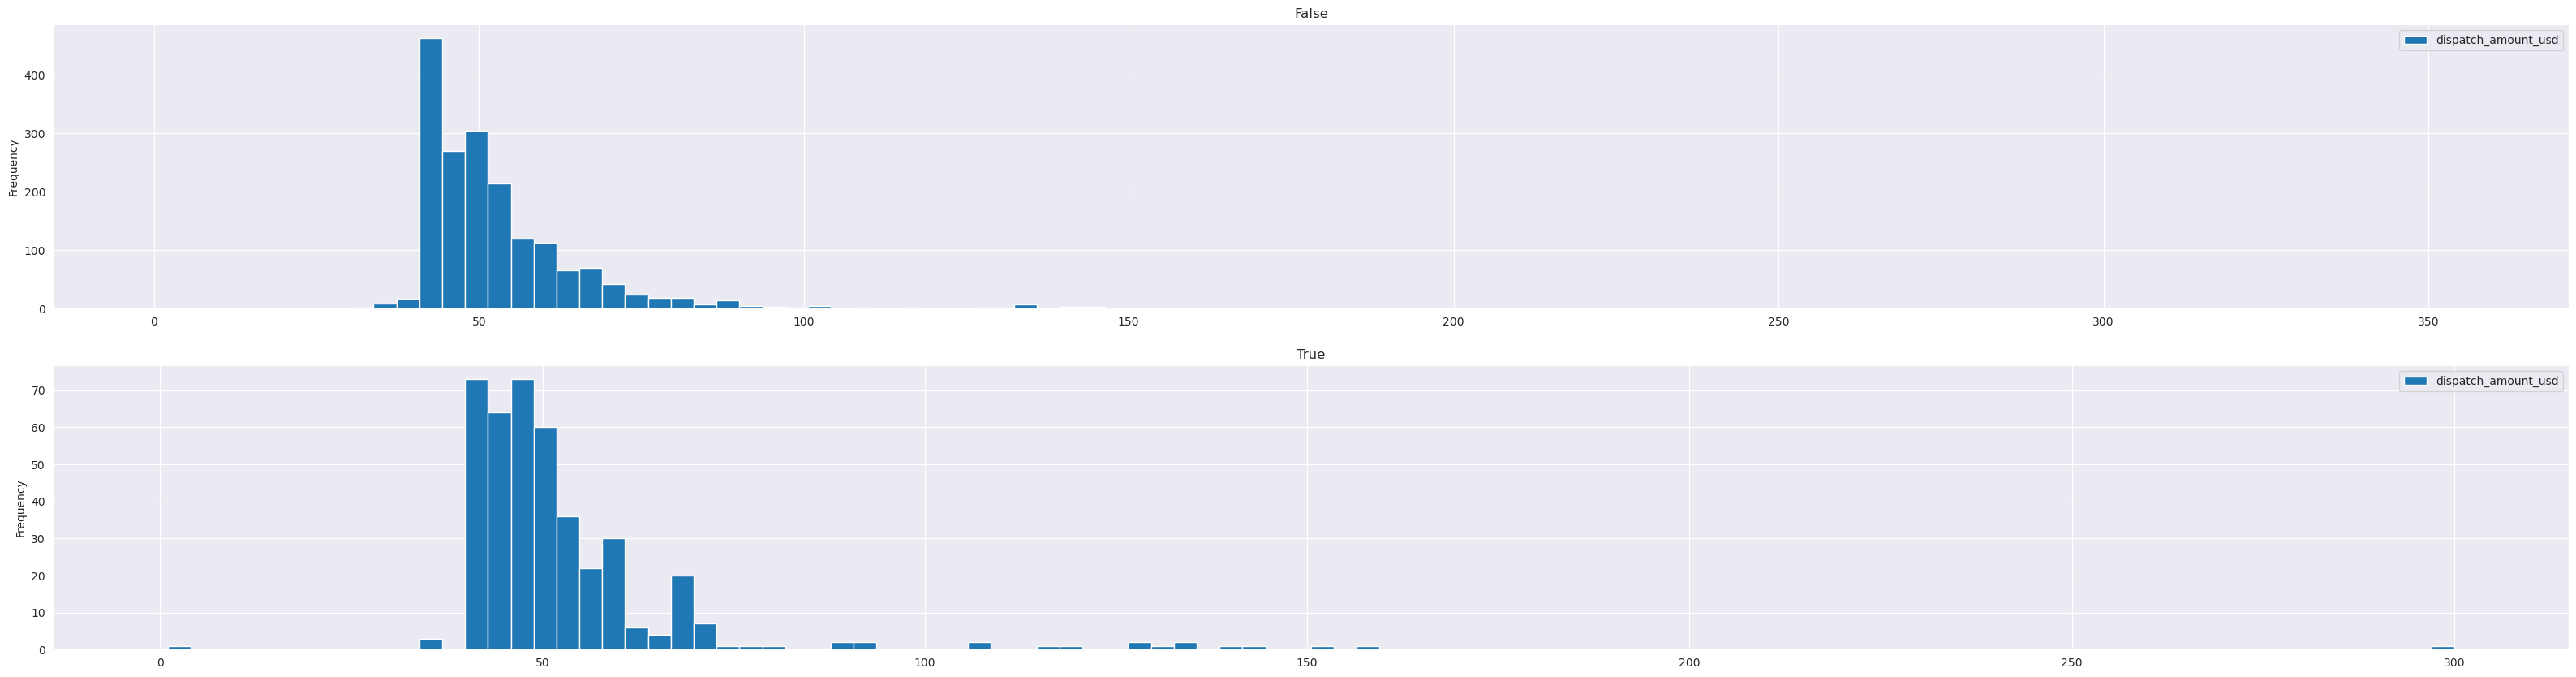

In [48]:
df_ride_deduplication.plot.hist(bins=100, column=['dispatch_amount_usd'], by='peak_time', figsize=(40,10))

In [49]:
# df_ride_deduplication['dispatch_amount_usd'].median()


In [50]:
c0 = df_ride_deduplication['holiday'] == False 
c1 = df_ride_deduplication['dayofweek'] < 5 
c2 = df_ride_deduplication['peak_time'] == False
c3 = df_ride_deduplication['nighttime'] == False
df_ride_base = df_ride_deduplication[c0 & c1 & c2 & c3] 
df_ride_base

,ride_id,level_1,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,...,weekday,dayofweek,country_alpha_2,country_subdiv,holiday,peak_time,nighttime,cost,profit,profit_rate
0,2184756,4483,41298,2021-07-30 15:30:00,Asia/Tokyo,2021-07-29 12:29:23.000000,2021-07-29 12:29:23.000000,35.54939,139.77984,35.69667,...,Friday,4,JP,8,False,False,False,72.515174,27.484826,0.379022
3,2192460,4407,59140,2021-09-17 14:30:00,Japan Standard Time,2021-09-13 23:25:08.000000,2021-09-13 23:25:08.000000,35.54939,139.77984,35.70100,...,Friday,4,JP,8,False,False,False,72.915840,17.084160,0.234300
13,2389159,4534,779943,2023-03-22 19:10:00,Japan Standard Time,2022-11-04 00:24:14.000000,2023-04-04 07:27:50.000000,35.54939,139.77984,35.70334,...,Wednesday,2,JP,8,False,False,False,41.237712,37.512288,0.909660
31,2397264,561,515723,2022-11-22 10:00:00,Asia/Tokyo,2022-11-20 22:08:36.000000,2022-11-20 22:08:36.000000,35.54827,139.78830,35.70014,...,Tuesday,1,JP,8,False,False,False,49.895754,-0.395754,-0.007932
33,2397288,1775,515770,2022-12-14 11:35:00,Asia/Tokyo,2022-11-20 23:41:18.000000,2022-11-20 23:41:18.000000,35.54827,139.78830,35.68588,...,Wednesday,2,JP,8,False,False,False,47.907920,1.592080,0.033232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4867,3511384,5139,2760920,2024-06-07 12:50:00,Japan Standard Time,2024-06-04 06:03:43.000000,2024-06-04 07:17:24.000000,35.77199,140.39285,35.65526,...,Friday,4,JP,8,False,False,False,89.630280,6.140972,0.068514
4874,3513156,112,2769542,2024-06-06 19:00:00,Japan Standard Time,2024-06-05 02:01:22.000000,2024-06-06 07:20:20.000000,35.54465,139.76779,35.65479,...,Thursday,3,JP,8,False,False,False,48.228196,15.901804,0.329720
4877,3515429,81,2769026,2024-10-16 10:30:00,Asia/Tokyo,2024-06-06 03:47:59.000000,2024-06-06 03:47:59.000000,35.54465,139.76779,35.71546,...,Wednesday,2,JP,8,False,False,False,56.677663,10.822337,0.190945
4879,3515511,4907,2769191,2024-06-12 22:00:00,Asia/Tokyo,2024-06-06 05:03:55.000000,2024-06-06 05:03:55.000000,35.55230,139.78000,35.69776,...,Wednesday,2,JP,8,False,False,False,48.152008,13.653842,0.283557


In [51]:
cost_median = df_ride_base['cost'].median()
idx = (df_ride_base['cost'] - cost_median).abs().idxmin()
idx

np.int64(1890)

In [52]:
cost_profit = df_ride_base.loc[idx,'profit']
partner_id = df_ride_base.loc[idx,'partner_id']
(cost_median, cost_profit,partner_id)

(np.float64(44.457087407491294), np.float64(8.311592551406463), np.int64(2))

<Axes: ylabel='Frequency'>

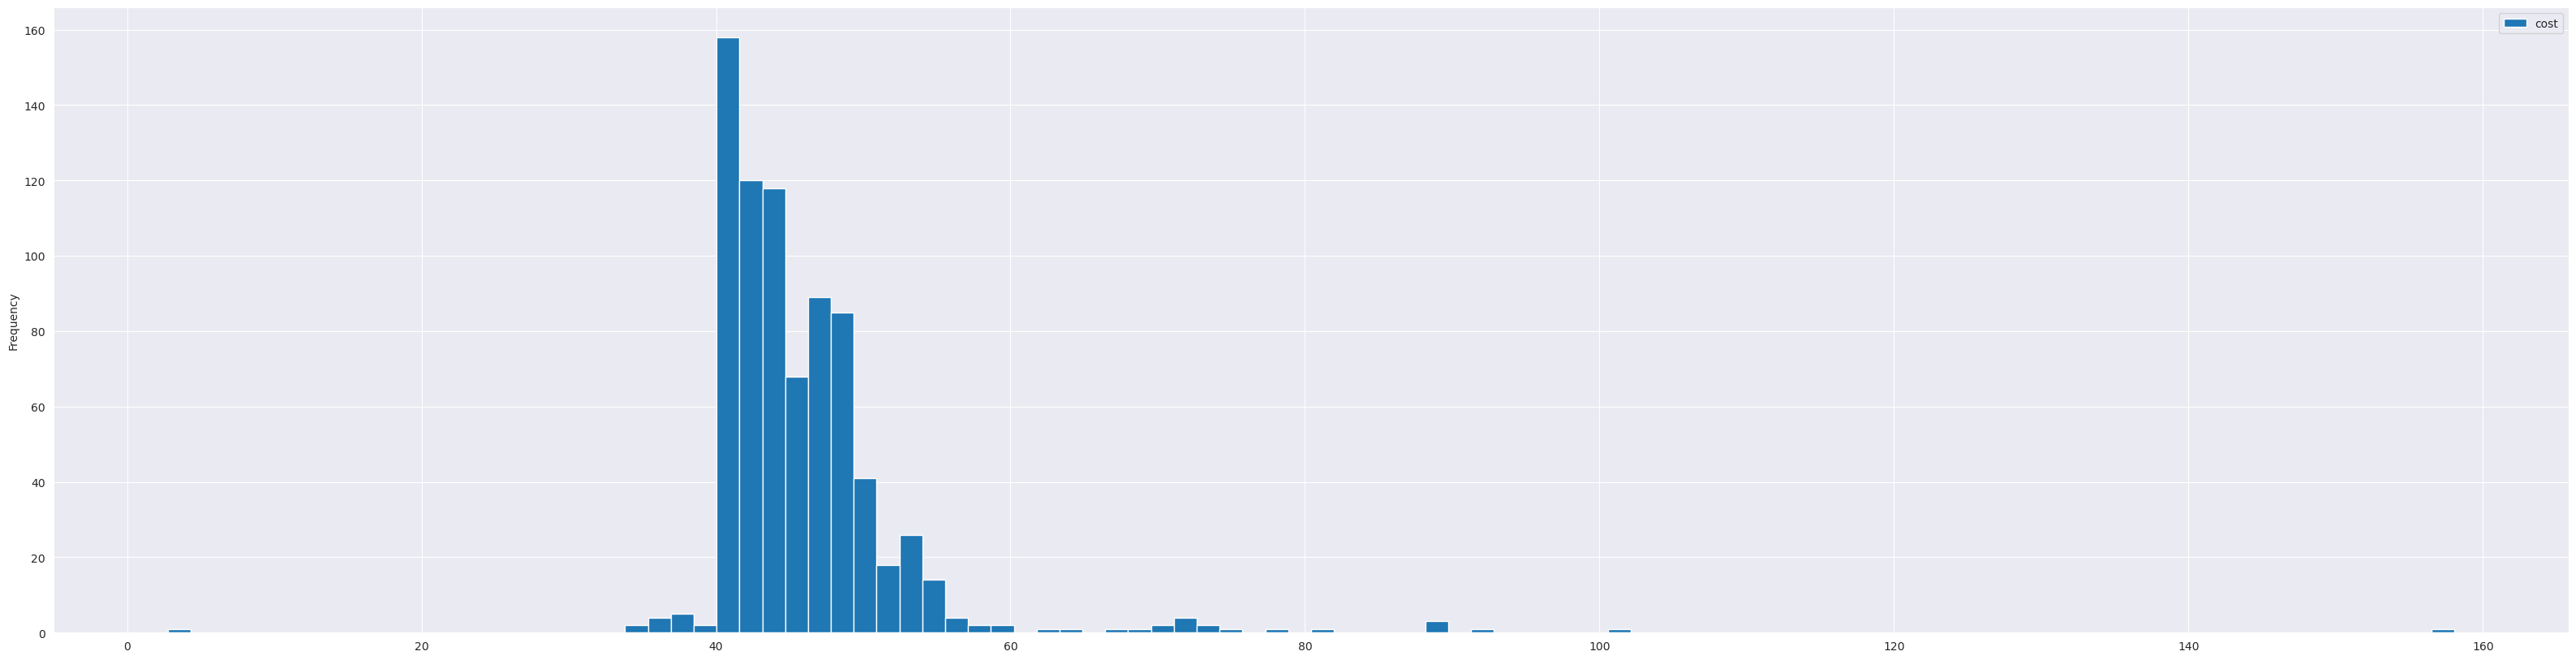

In [53]:
df_ride_base.plot.hist(bins=100, column=['cost'], figsize=(40,10))

In [54]:
query_input.loc[['route_start','route_end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','trip_count','trip_no']]

route_start           HND
route_end             东京2
dispatch_amount     55.06
partner_id              2
vehicle_class_id      1.0
service_area_id        43
trip_count              1
trip_no                -1
Name: 1257019, dtype: object

<Axes: ylabel='Frequency'>

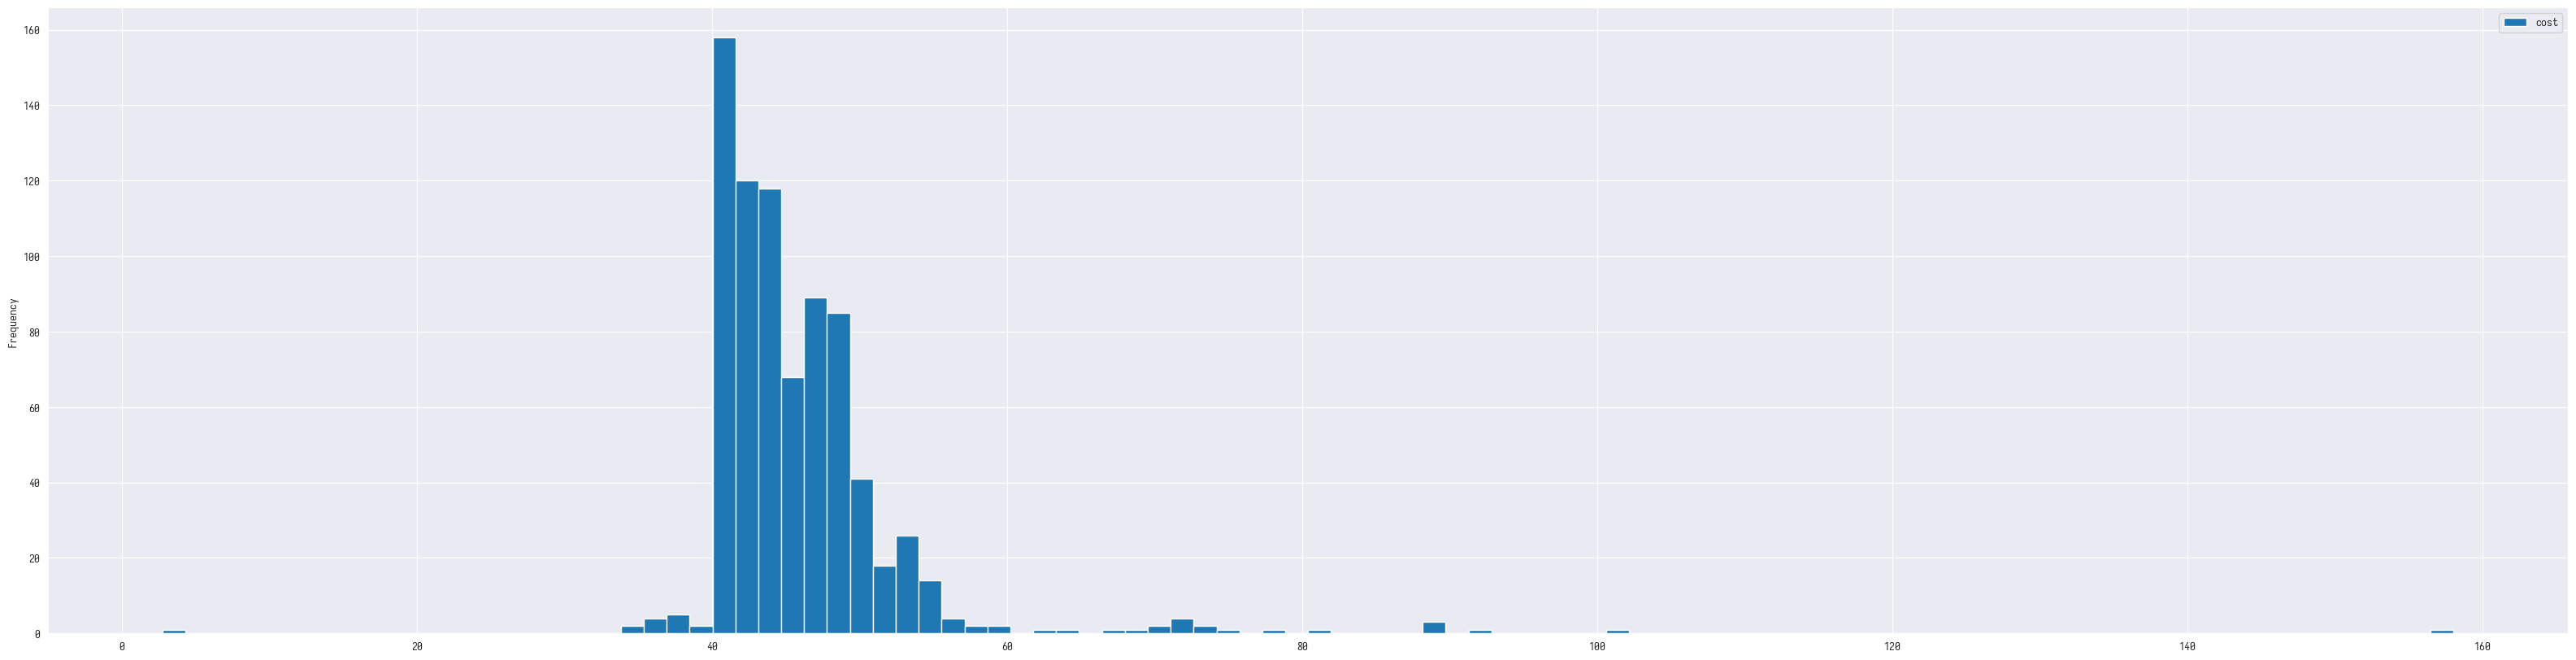

In [55]:
cost_dist = df_ride_base['cost']

plt.rcParams['font.family'] = ['Sarasa Term SC Nerd']
plt.rcParams['axes.unicode_minus']=False
df_ride_base.plot.hist(bins=100, column=['cost'], figsize=(40,10))

<Axes: ylabel='Frequency'>

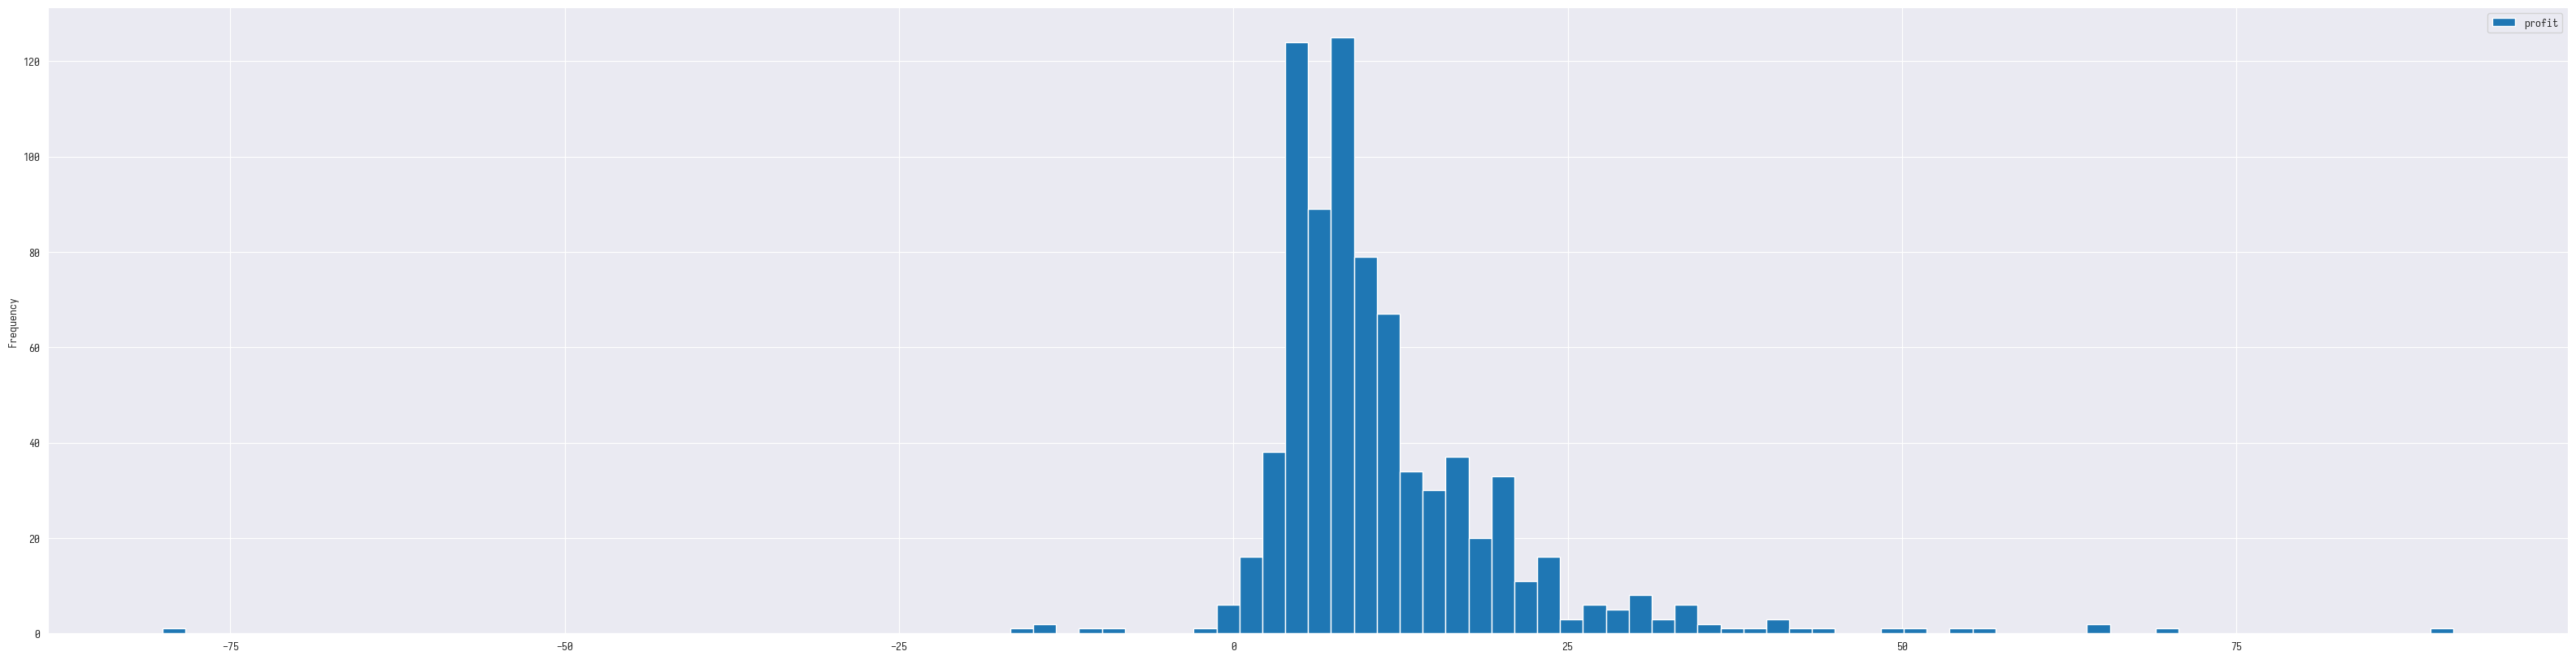

In [56]:
df_ride_base.plot.hist(bins=100, column=['profit'], figsize=(40,10))

In [57]:
# warnings.filterwarnings("ignore", message="The Argentina data file contains 4-digit postal codes which were replaced with a new system in 1999.")
# warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.")
# pd.set_option('future.no_silent_downcasting', True)
# p0 = datetime.strptime('07:00:00', '%H:%M:%S').time()
# p1 = datetime.strptime('09:00:00', '%H:%M:%S').time()
# p2 = datetime.strptime('16:00:00', '%H:%M:%S').time()
# p3 = datetime.strptime('19:00:00', '%H:%M:%S').time()
# n0 = datetime.strptime('22:00:00', '%H:%M:%S').time()
# n1 = datetime.strptime('06:00:00', '%H:%M:%S').time()
# peak_time_str = [(p0, p1), (p2, p3)]
# night_time_str = [(n0, n1)] # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am
# 
# subdv_code = ('','')
# local_holidays = None
# 
# def get_state_code(country_name,city_name):
#     # cn=coco.convert(country_name, to='name_short')
#     cntry = pycountry.countries.search_fuzzy(country_name)[0]
#     nomi = pgeocode.Nominatim(cntry.alpha_2)
#     df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
#     # df_nomi = df_nomi[city_name.lower() == df_nomi['place_name'].apply(lambda x: x.lower())]
#     if df_nomi.empty:
#         return None
# 
#     # r0 = df_nomi[['country_code', 'place_name', 'state_code', 'county_code']].iloc[0]
#     state_code = df_nomi['state_code'].iloc[0]
#     return state_code
# 
# def get_country_and_state_codes_from_geocoord(latitude, longitude):
#     geolocator = Nominatim(user_agent="geocodequery")
#     location = geolocator.reverse((latitude, longitude), exactly_one=True)
# 
#     if location:
#         address = location.raw['address']
#         country_code = address.get('country_code', None)
#         state_code = address.get('state_code', None)
# 
#         return (country_code.upper(), state_code)
# 
#     return (None, None)
# 
# def feature_extraction(x):
#     global subdv_code, local_holidays
#     x.loc['dispatch_amount_usd'] = x['dispatch_amount'] / x['rate']
#     x.loc['weekday'] = x['from_datetime'].day_name()
#     x.loc['dayofweek'] = x['from_datetime'].weekday()
#     x.loc['country_alpha_2'] = subdv_code[0]
#     x.loc['country_subdiv'] = subdv_code[1]
#     x.loc['holiday'] = x['from_datetime'] in local_holidays
#     t = x['from_datetime'].time()
#     x.loc['peak_time'] = p0 < t < p1 or p2 < t < p3
#     x.loc['nighttime'] = n0 < t or t < n1
#     return x
# 
# def cost_profit_extraction(x):
#     cost = x[x['trip_no']>=0]['dispatch_amount_usd'].mean()
#     x['cost'] = cost
#     profit = x[x['trip_no']==-1]['dispatch_amount_usd'].mean()/x['trip_count'].mean() - cost
#     x['profit'] = profit 
#     # x['profit_rate'] = profit/ cost 
#     
#     return x
# 
# def cost_prediction(service_area_id, route_from_zone, route_to_zone, vehicle_class_id, update_flag=False):
#     global fpz_lut_t
#     global fpz_query_t
#     global subdv_code
#     global local_holidays
# 
#     if update_flag == False:
#         cache_hit_t = (
#             select(fpz_query_t)
#             .where(
#                 and_(
#                     fpz_query_t.c.start == route_from_zone,
#                     fpz_query_t.c.end == route_to_zone,
#                     fpz_query_t.c.service_area_id == int(service_area_id),
#                     fpz_query_t.c.vehicle_class_id == int(vehicle_class_id),
#                 )
#             )
#             .select_from(fpz_query_t)
#         )
#         rp = gbq_conn.execute(cache_hit_t)
#         results = rp.fetchall()
#         if len(results) > 0:
#             # prediction = (results[0]['cost'], results[0]['profit'])
#             cost, profit = (results[0][3],results[0][4])
#             cost = f"{cost:,.2f}"
#             profit = f"{profit:,.2f}"
#             prediction = (cost, profit)
#             return prediction
#         else:
#             print("No cache hit")
#             
#     route_hist_dispatches = (
#         select(fpz_lut_t)
#         .where(
#             and_(
#                 fpz_lut_t.c.route_start == route_from_zone,
#                 fpz_lut_t.c.route_end == route_to_zone,
#                 fpz_lut_t.c.service_area_id == int(service_area_id),
#                 fpz_lut_t.c.vehicle_class_id == int(vehicle_class_id),
#                 # fpz_lut_t.c.trip_no > -1,
#             )
#         )
#         .select_from(fpz_lut_t)
#     )
# 
#     # Execute the statement and fetch the results
#     print("Executing query")
#     df_query = pd.read_sql(route_hist_dispatches, gbq_eng)
#     print("Query executed")
#     assert df_query.shape[0] != 0, "No data available for prediction"
# 
#     df_query = df_query.astype({
#         'from_datetime_fix_str': 'datetime64[ms]',
#         'vehicle_class_id': 'int64',
#         'passenger_count': 'int64',
#         'trip_count': 'int64',
#         'trip_no': 'int64',
#     })
#     df_query.rename(columns={'from_datetime_fix_str': 'from_datetime'}, inplace=True)
#     df_query = df_query.drop_duplicates(subset='dispatch_id', keep='first')
# 
#     cntry_name = df_query['service_area'][0].rsplit(',',1)[-1].lstrip()
#     cntry_name = coco.convert(cntry_name, to='name_short')
#     cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
#     country_code = cntry_obj.alpha_2
#     cty_name = df_query['service_area'][0].rsplit(',',2)[-2].lstrip()
#     state_code = get_state_code(cntry_name,cty_name)
# 
#     try:
#         local_holidays = holidays.country_holidays(country=country_code, subdiv=state_code, years=2024)
#     except NotImplementedError:
#         print(f'No holidays for this subdivision of the country {subdv_code[0]}')
#         local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
#     
#     df_query = df_query.apply(feature_extraction, axis=1)
#     df_valid_samples = (df_query.groupby('ride_id').apply(cost_profit_extraction, include_groups=False)
#                         .dropna(subset=['cost','profit','profit_rate'], how='any'))
#     df_valid_samples = df_valid_samples.reset_index().drop_duplicates(subset=['ride_id'],keep='first')
# 
#     c_0 = df_valid_samples ['holiday'] == False
#     c_1 = df_valid_samples ['dayofweek'] < 5
#     c_2 = df_valid_samples ['peak_time'] == False
#     c_3 = df_valid_samples ['nighttime'] == False
#     df_valid_samples = df_valid_samples [c_0 & c_1 & c_2 & c_3]
#     assert df_valid_samples.shape[0] != 0, "No data available for prediction"
#     cost = float(df_valid_samples['cost'].median())
#     idx = (df_valid_samples['cost'] - cost).abs().idxmin()
#     profit = float(df_valid_samples.loc[idx,'profit'])
#     ptnr_id = int(df_valid_samples.loc[idx,'partner_id'])
# 
#     df_fpz_route = pd.DataFrame([{
#         "start": route_from_zone,
#         "end": route_to_zone,
#         "partner_id": ptnr_id,
#         "cost": cost,
#         "profit": profit,
#         "service_area_id": int(service_area_id),
#         "vehicle_class_id": int(vehicle_class_id),
#     }])
#     pandas_gbq.to_gbq(df_fpz_route, 
#                       "price.fixed_zone_routes", 
#                       project_id="elife-data-warehouse-test", 
#                       if_exists="replace")
#         
#     
#     cost = f"{cost:,.2f}"
#     profit = f"{profit:,.2f}"
#     prediction = (cost, profit)
#     
#     return prediction
# 
# # service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
# # predicted_cost = cost_prediction(service_area_id,
# #                                  route_from_zone,
# #                                  route_to_zone,
# #                                  vehicle_class_id,
# #                                  update_flag=True)
# # 
# # predicted_cost
# 


In [58]:
# sql_eng2 = create_engine('sqlite:///../data/price_2324.db', echo=False)
# sql_conn2 = sql_eng2.connect()
# sql_metadata2 = MetaData()
# Sql_Session2 = sessionmaker(bind=sql_eng2)
# sql_session2 = Sql_Session2()

routes_t = Table('routes_vehicle_tokyo', sql_metadata, autoload_with=sql_eng)
total_rows = sql_session.query(routes_t).count()
print(total_rows)

446


In [194]:
df_routes_vehicle_class = pd.read_sql(select(routes_t), sql_conn)
df_routes_vehicle_class.shape

(446, 59)

In [195]:
# df_routes_vehicle_class.to_sql('routes_vehicle_class_2324', sql_eng2, if_exists='replace', index=False)

In [59]:
service_areas_2324_fix_t = Table('service_areas_2324_fix', sql_metadata, autoload_with=sql_eng)
df_service_areas_fix = pd.read_sql(select(service_areas_2324_fix_t), sql_conn, index_col='service_area_id')
df_service_areas_fix


,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,...,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end,cost,profit,service_area_fix,holidays
service_area_id,,,,,,,,,,,,,,,,,,,,,
55,49.19669,-123.18151,49.28247,-123.11861,87749,183908,2206773,1,1693854000.0,2023-09-04 12:00,...,49.2824692,1.0,Sedan,1,YVR,Vancouver,,,"Vancouver,Canada",11
99,29.65561,-95.27792,29.3081,-94.79726,101558,52498,2213222,1,1702665000.0,2023-12-15 12:30,...,29.3080971,3.0,MPV-5,1,HOU,"Galveston, TX",,,"Houston,USA",13
38,37.61487,-122.38985,37.79414,-122.40779,123241,128980,2222284,1,1740210300.0,2025-02-21 23:45,...,37.7941378,1.0,Sedan,1,SFO,san francisco,,,"San Francisco, USA",14
165,19.43608,-99.07191,19.28447,-99.14919,140298,68154,2230107,1,1682031600.0,2023-04-20 17:00,...,19.2844672,1.0,Sedan,1,MEX,Mexico city south,,,"Mexico City,Mexico",8
40,40.75203,-73.98472,40.64131,-73.77814,155022,84728,2238054,1,1672849800.0,2023-01-04 11:30,...,40.6413111,6.0,MPV-4,1,曼哈顿,JFK,,,"New York,USA",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,51.97723,7.61082,52.1346,7.68483,2705826,113316,3486413,1,1722760500.0,2024-08-04 10:35,...,52.134602,1.0,Sedan,1,Münster,FMO,,,"Greven, Germany",9
1158,54.0833,-4.62389,54.18296,-4.47545,2774762,115116,3512920,1,1717831800.0,2024-06-08 08:30,...,54.1829572,1.0,Sedan,1,IOM,Douglas,,,Isle of Man,10
1419,46.62088,14.30649,46.65001,14.32486,2779550,102324,3520706,1,1718618400.0,2024-06-17 12:00,...,46.6500125,6.0,MPV-4,1,Klagenfurt,KLU,,,"Klagenfurt,Austria",13


In [61]:
# dispatch_routes_t = Table('dispatch_feature_routes_2324_sa_fix', sql_metadata, autoload_with=sql_eng)
dispatch_routes_t = Table('dispatch_feature_routes_tokyo', sql_metadata, autoload_with=sql_eng)
total_rows = sql_session.query(dispatch_routes_t).count()
print(total_rows)

26131


In [62]:

df_dispatch_routes = pd.read_sql(select(dispatch_routes_t), sql_conn) # index_col='dispatch_id')  #sqlite3
df_dispatch_routes

,dispatch_id,from_datetime_fix_str,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end,service_area_fix,holidays
0,753,2020-11-01 13:30:00,Japan Standard Time,2020-06-28 07:38:00.000000,2020-06-28 07:38:00.000000,35.54939,139.77984,35.72174,139.78053,2165132,...,2.0,5.0,0.0,0.0,21973.0,1413.0,HND,东京2,"Tokyo, Japan",21
1,1162,2020-07-14 17:00:00,Japan Standard Time,2020-07-11 20:10:11.000000,2020-07-11 20:10:11.000000,35.54939,139.77984,35.66197,139.70380,2165337,...,1.0,5.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
2,1163,2020-07-14 17:00:00,Japan Standard Time,2020-07-11 20:10:11.000000,2020-07-11 20:10:31.000000,35.54939,139.77984,35.66197,139.70380,2165337,...,1.0,5.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
3,1238,2020-07-15 22:15:00,Japan Standard Time,2020-07-14 01:51:19.000000,2020-07-14 01:51:19.000000,35.54939,139.77984,35.66197,139.70380,2165375,...,1.0,3.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
4,1239,2020-07-15 22:15:00,Japan Standard Time,2020-07-14 01:51:19.000000,2020-07-14 01:51:27.000000,35.54939,139.77984,35.66197,139.70380,2165375,...,1.0,3.0,0.0,0.0,20066.0,1420.0,HND,东京2,"Tokyo, Japan",21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26126,3489456,2024-10-14 15:10:00,Asia/Tokyo,2024-06-08 21:19:07.000000,2024-10-12 08:11:42.000000,35.54465,139.76779,35.68783,139.69849,3521511,...,5.0,5.0,NaN,NaN,24754.0,2100.0,HND,东京2,"Tokyo, Japan",21
26127,3489459,2024-10-14 15:10:00,Asia/Tokyo,2024-06-08 21:19:07.000000,2024-10-12 08:12:34.000000,35.54465,139.76779,35.68783,139.69849,3521511,...,5.0,5.0,NaN,NaN,24754.0,2100.0,HND,东京2,"Tokyo, Japan",21
26128,3495011,2024-10-15 07:15:00,Asia/Tokyo,2024-04-24 15:23:34.000000,2024-10-13 09:02:17.000000,35.54465,139.76779,35.69571,139.70227,3424156,...,5.0,5.0,NaN,NaN,25723.0,2400.0,HND,东京2,"Tokyo, Japan",21
26129,3519099,2024-10-25 17:30:00,Asia/Tokyo,2024-06-08 05:13:43.000000,2024-10-16 22:41:00.000000,35.54465,139.76779,35.71139,139.77288,3520019,...,3.0,3.0,NaN,NaN,22317.0,1670.0,HND,东京2,"Tokyo, Japan",21


In [63]:
query_input = df_dispatch_routes.iloc[10000,:]  # 1000
# query_input = df_dispatch_routes[df_dispatch_routes['service_area_id'] == 133].iloc[0,:]
# query_input[['start','end']]
# query_input.loc[['dispatch_id','start','end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','trip_count','trip_no']]
query_input['route_start'], query_input['route_end'], query_input['dispatch_amount'], query_input['service_area_id'], query_input['vehicle_class_id']
ltt, lng = query_input['start_ltt_lp'], query_input['start_lng_lp']
ltt, lng



('HND', '东京2', np.float64(55.06), np.int64(43), np.float64(1.0))

(np.float64(35.54827), np.float64(139.7883))

In [64]:
# df = pd.read_sql(select(dispatch_routes_t),con=sql_conn2)
# df.head()
# df.shape

In [65]:

routes_t = Table('dispatch_feature_routes_tokyo', sql_metadata, autoload_with=sql_eng)
total_rows = sql_session.query(routes_t).count()
print(total_rows)

pd.options.mode.copy_on_write = True
max_concurrent = 48
chunk_size=100
non_cp_count = 0
routes_q = select(routes_t)


26131


In [67]:
CostQueryStatus = Enum('CostQueryStatus', 'NoCountryCode NoStateCode NoHistorySamples Success')
cost_profit = {'cost': None, 'profit': None}
local_holidays = None

def country_and_state_codes_from_geocoord(latitude, longitude):
    geolocator = Nominatim(user_agent="geocodequery")
    location = geolocator.reverse((latitude, longitude), exactly_one=True)

    if location:
        address = location.raw['address']
        country_code = address.get('country_code', None)
        state_code = address.get('state_code', None)

        return (country_code.upper(), state_code)

    return (None, None)

# country_and_state_codes_from_geocoord(ltt, lng)

def feature_extract(x):
    global local_holidays
    x.loc['dispatch_amount_usd'] = x['dispatch_amount'] / x['rate']
    x.loc['weekday'] = x['from_datetime'].day_name()
    x.loc['dayofweek'] = x['from_datetime'].weekday()
    # x.loc['country_alpha_2'] = subdv_code[0]
    # x.loc['country_subdiv'] = subdv_code[1]
    if local_holidays:
        x.loc['holiday'] = x['from_datetime'] in local_holidays
    else:
        x.loc['holiday'] = False
    t = x['from_datetime'].time()
    x.loc['peak_time'] = p0 < t < p1 or p2 < t < p3
    x.loc['nighttime'] = n0 < t or t < n1
    return x

def cost_profit_extract(x):
    cost = x[x['trip_no']>=0]['dispatch_amount_usd'].mean()
    x['cost'] = cost
    profit = x[x['trip_no']==-1]['dispatch_amount_usd'].mean()/x['trip_count'].mean() - cost
    x['profit'] = profit
    # x['profit_rate'] = profit/ cost 

    return x

def cost_prediction_sql(service_area_id, route_from_zone, route_to_zone, vehicle_class_id) -> CostQueryStatus: 
    global cost_profit,local_holidays
    route_hist_dispatches = (
        select(dispatch_routes_t)
        .where(
            and_(
                dispatch_routes_t.c.route_start == route_from_zone,
                dispatch_routes_t.c.route_end == route_to_zone,
                dispatch_routes_t.c.service_area_id == int(service_area_id),
                dispatch_routes_t.c.vehicle_class_id == int(vehicle_class_id),
            )
        )
        .select_from(dispatch_routes_t)
    )
    
    # Execute the statement and fetch the results
    # print("Executing query")
    df_query = pd.read_sql(route_hist_dispatches, sql_eng)
    # print("Query executed")
    if df_query.shape[0] == 0: # "No data available for prediction"
        return CostQueryStatus.NoHistorySamples
    
    df_query = df_query.astype({
        'from_datetime_fix_str': 'datetime64[ms]',
        'vehicle_class_id': 'int64',
        # 'passenger_count': 'int64',
        'trip_count': 'int64',
        'trip_no': 'int64',
    })
    df_query.rename(columns={'from_datetime_fix_str': 'from_datetime'}, inplace=True)
    df_query = df_query.drop_duplicates(subset='dispatch_id', keep='first')

    ltt_start = df_query['start_ltt_lp'][0]
    lng_start = df_query['start_lng_lp'][0]
    # country_code, state_code = country_and_state_codes_from_geocoord(ltt_start, lng_start)
    service_area_str = df_query['service_area_fix'][0]
    comma_counts = service_area_str.count(',')
    # print(service_area_str)

    match comma_counts:
        case 0:
            try:
                cntry_name = service_area_str
                cntry_name = coco.convert(cntry_name, to='short_name')
                if cntry_name == 'not found':
                    return CostQueryStatus.NoCountryCode
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case 1:
            try:
                cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
                if cntry_name != "Virgin Islands of the United States":
                    cntry_name = coco.convert(cntry_name, to='short_name')
                    if cntry_name == 'not found':
                        return CostQueryStatus.NoCountryCode
                city_name = service_area_str.rsplit(',',2)[-2].lstrip()
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                try:
                    nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
                    df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
                    if df_nomi.empty:
                        state_code = None
                    else:
                        state_code = df_nomi['state_code'].iloc[0]
                except ValueError:
                    state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case 2:
            try:
                cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
                cntry_name = coco.convert(cntry_name, to='short_name')
                if cntry_name == 'not found':
                    return CostQueryStatus.NoCountryCode
                state_code = service_area_str.rsplit(',',2)[-2].lstrip()
                city_name = service_area_str.rsplit(',',3)[-3].lstrip()
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                if cntry_name != "USA":
                    try:
                        nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
                        df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
                        if df_nomi.empty:
                            state_code = None
                        else:
                            if state_code == df_nomi['state_code'].iloc[0]:
                                state_code = df_nomi['state_code'].iloc[0]
                            else:
                                state_code = None
                    except ValueError:
                        state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case _:
            return CostQueryStatus.NoCountryCode

    if state_code == None:
        try:
            local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
        except Exception as exc:
            local_holidays = None
    else:
        try:
            local_holidays = holidays.country_holidays(cntry_obj.alpha_2, subdiv=state_code,years=2024)
        except NotImplementedError:
            try:
                local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
            except Exception as exc:
                local_holidays = None

    df_query = df_query.apply(feature_extract, axis=1)
    df_valid_samples = (df_query.groupby('ride_id').apply(cost_profit_extract, include_groups=False)
                        .dropna(subset=['cost','profit'], how='any'))
    df_valid_samples = df_valid_samples.reset_index().drop_duplicates(subset=['ride_id'],keep='first')
    
    c_0 = df_valid_samples['holiday'] == False
    c_1 = df_valid_samples['dayofweek'] < 5
    c_2 = df_valid_samples['peak_time'] == False
    c_3 = df_valid_samples['nighttime'] == False
    df_valid_samples = df_valid_samples [c_0 & c_1 & c_2 & c_3]
    if df_valid_samples.shape[0] == 0: # "No data available for prediction"
        return CostQueryStatus.NoHistorySamples
    cost = float(df_valid_samples['cost'].median())
    idx = (df_valid_samples['cost'] - cost).abs().idxmin()
    profit = float(df_valid_samples.loc[idx,'profit'])
    # ptnr_id = int(df_valid_samples.loc[idx,'partner_id'])
   
    cost_profit['cost'] = cost
    cost_profit['profit'] = profit
    return CostQueryStatus.Success

# service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
# status = cost_prediction_sql(service_area_id, route_from_zone, route_to_zone, vehicle_class_id)
# status
# cost_profit

for i,chunk in enumerate(tqdm(pd.read_sql(routes_q,sql_conn,index_col='ride_inserted_at', chunksize=chunk_size),     total=total_rows//chunk_size+1, desc='Overall Progress')):
    # get_fixed_zone_chunk(chunk)

    chunk = chunk.dropna(subset=['service_area_id','route_start','route_end','vehicle_class_id'],how='any')
    non_cost_profit_count_chunk = chunk_size - chunk.shape[0]
    # with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
    #     to_do_map = {} # list[futures.Future] = [] 
    #     for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
    #     # for ind,r in chunk.iterrows():
    #         future = executor.submit(cost_prediction_sql, r['service_area_id'], r['route_start'], r['route_end'], r['vehicle_class_id'])
    #         to_do_map[future] = ind
    #     done_iter = as_completed(to_do_map)
    #     done_iter = tqdm(done_iter, total=len(to_do_map), desc='chunk progress', leave=False)
    # 
    #     for future in done_iter:
    #         try:
    #             status = future.result()
    #         except Exception as e:
    #             # print(f"Exception: {e}")
    #             continue
    # 
    #         if status == CostQueryStatus.Success:
    #             ind = to_do_map[future]
    #             try:
    #                 chunk.loc[ind, 'cost'] = cost_profit['cost']
    #                 chunk.loc[ind, 'profit'] = cost_profit['profit']
    #             except KeyError as e:
    #                 non_cost_profit_count_chunk += 1
    #                 # print(f"\r {e}: {non_cost_profit_count_chunk}/{chunk_size}")
    #                 continue
    #             except Exception as e:
    #                 non_cost_profit_count_chunk += 1
    #                 # print(f"\r {e}: {non_cost_profit_count_chunk}/{chunk_size}")
    #                 continue
    #         else:
    #             non_cost_profit_count_chunk += 1
    #             # print(f"\r non fzp chunk: {non_cost_profit_count_chunk}/{chunk_size}")
    #             continue
                
    for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
        # for ind,r in chunk.iterrows():
        status = cost_prediction_sql(r['service_area_id'], r['route_start'], r['route_end'], r['vehicle_class_id'])

        if status == CostQueryStatus.Success:
            try:
                # print(f"{r['service_area_id']}, {r['route_start']}, {r['route_end']}, {r['vehicle_class_id']}: {cost_profit}")
                chunk.loc[ind, 'cost'] = cost_profit['cost']
                chunk.loc[ind, 'profit'] = cost_profit['profit']
            except KeyError as exc:
                non_cost_profit_count_chunk += 1
                # print(f"\r {exc}: {non_cost_profit_count_chunk}/{chunk_size}")
                continue
            except Exception as exc:
                non_cost_profit_count_chunk += 1
                # print(f"\r {exc}: {non_cost_profit_count_chunk}/{chunk_size}")
                continue
        else:
            non_cost_profit_count_chunk += 1
            # print(f"\r non fzp chunk: {non_cost_profit_count_chunk}/{chunk_size}")
            continue
            
    non_cp_count += non_cost_profit_count_chunk
    scanned_row_number = (i+1)*chunk_size
    try:
        # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
        with open('../data/routes_vehicle_class_tokyo.csv', 'a') as f:
            chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
        # chunk.to_csv(path_or_buf=csv_result_file_list[0],mode='a',chunksize=chunk_size)
        # chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
        print(f"\r Non_FZP count: {non_cp_count}/{scanned_row_number}")
    except Exception as e:
        print(f"\r {e}, Non_FZP count: {non_cp_count}/{scanned_row_number} ")
        continue


Overall Progress:   0%|          | 0/262 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

 Non_FZP count: 1/100


chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

 Non_FZP count: 2/200


chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [53]:
query_input = df_dispatch_routes.iloc[12000,:]  # 1000
service_area_id, route_from_zone, route_to_zone, vehicle_class_id = query_input.loc['service_area_id'], query_input.loc['route_start'], query_input.loc['route_end'], query_input.loc['vehicle_class_id']
service_area_id, route_from_zone, route_to_zone, vehicle_class_id

(np.int64(140), '南墨尔本', 'MEL', np.float64(1.0))

In [57]:
service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
service_area_id, route_from_zone, route_to_zone, vehicle_class_id

(133, 'European Side,İstanbul', 'IST', 3)

In [59]:
predicted_cost = cost_prediction(service_area_id,
                                 route_from_zone,
                                 route_to_zone,
                                 vehicle_class_id)

predicted_cost


TypeError: unsupported format string passed to NoneType.__format__

In [89]:

predicted_cost

('39.18', '14.31')

In [55]:
routes_count = routes_dispatches['count']
routes_count = routes_count.apply(lambda x: np.log(x))

<Axes: xlabel='route_start,route_end'>

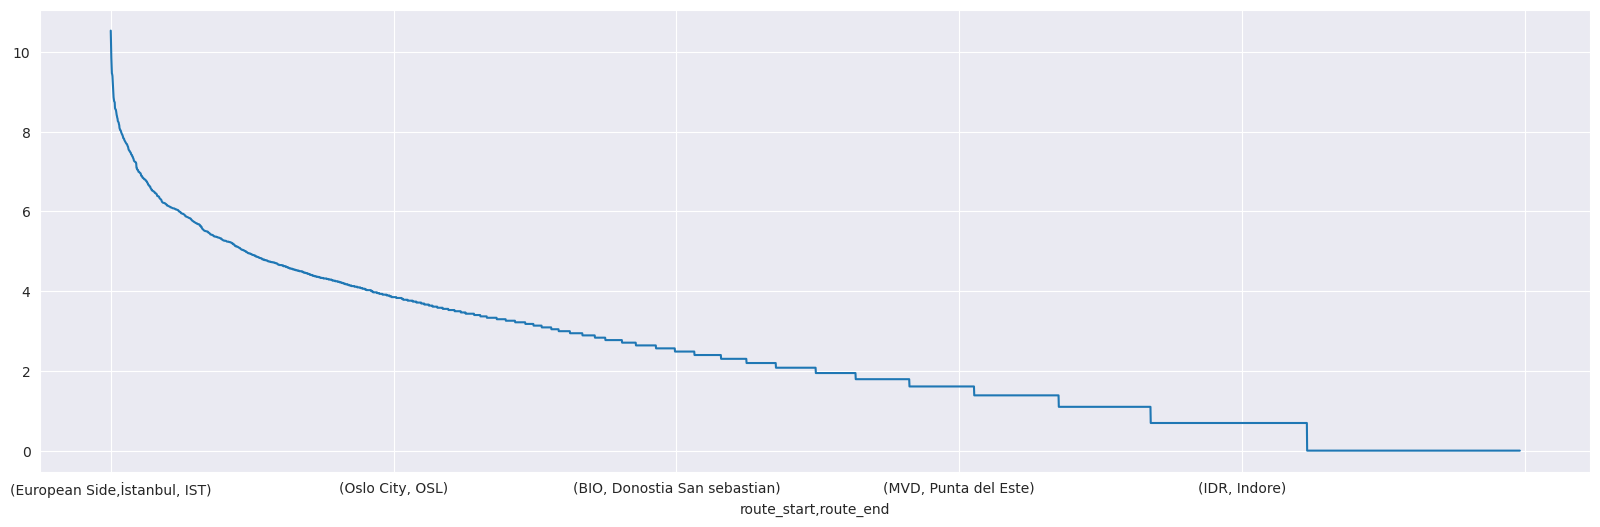

In [56]:
routes_count.plot(figsize=(20,6))
# routes_count


In [52]:
cumulative_count = routes_count.cumsum()
cumulative_count /= cumulative_count.iloc[-1]
cumulative_count = cumulative_count.apply(lambda x: np.log(x))

<Axes: xlabel='route_start,route_end'>

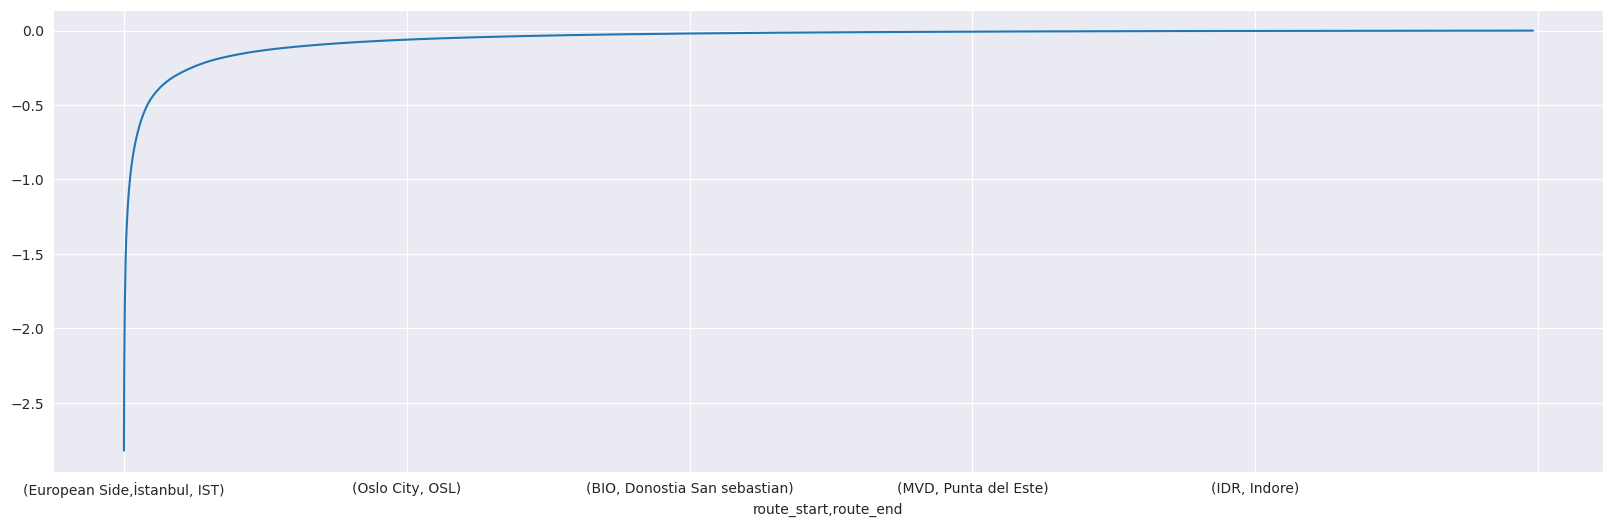

In [53]:

cumulative_count.plot(figsize=(20,6))

In [58]:
# df_routes = df.dropna(subset=['route_start', 'route_end'],how='all')
# len(df_routes)

631894

In [69]:
# # df_routes.set_index(['dispatch_id', 'route_end'], inplace=True)
# df_routes.iloc[:5,:]

,index,dispatch_id,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,route_start,route_end
0,0,2979402,-54.84330,-68.29580,-54.83495,-68.34771,USH,Ushuaia
1,1,2615870,-54.84330,-68.29580,-54.80621,-68.31104,USH,Ushuaia
2,2,2826367,-54.84330,-68.29580,-54.80621,-68.31104,USH,Ushuaia
3,3,1819243,-54.84330,-68.29580,-54.80264,-68.30629,USH,Ushuaia
4,4,2035026,-54.84330,-68.29580,-54.82094,-68.35159,USH,Ushuaia


In [23]:
# cols = df.columns
# cols

Index(['dispatch_id', 'start_ltt_lp', 'start_lng_lp', 'end_ltt_lp',
       'end_lng_lp', 'route_start', 'route_end'],
      dtype='object')

In [24]:

# cols = [c.name for c in query.subquery().columns]
# result = [dict(zip(cols, row)) for row in df.to_numpy()]
# # result = [row for row in df.to_numpy()]
# result

[{'dispatch_id': 2979402,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.83495',
  'end_lng_lp': '-68.34771',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2615870,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80621',
  'end_lng_lp': '-68.31104',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2826367,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80621',
  'end_lng_lp': '-68.31104',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 1819243,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80264',
  'end_lng_lp': '-68.30629',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2035026,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.82094',
  'end_lng_lp': '-68.35159',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id'

In [28]:

# from concurrent.futures import ThreadPoolExecutor, as_completed
# from concurrent import futures
# from enum import Enum
# 
# chunk_size = 1000
# non_fpz_count = 0
# max_concurrent = 24
# 
# connection2 = sql_eng.connect()


In [25]:
# query1000= query.limit(1000)
# chunk_size=100
# raw_total_rows = 1000
# # df = pd.read_sql(query1000, sql_eng)
# # df
# for i,chunk in enumerate(tqdm(pd.read_sql(query1000,connection,index_col='dispatch_id', chunksize=chunk_size), total=raw_total_rows//chunk_size+1, desc='Overall Progress')):
#     # for chunk in tqdm(pd.read_csv(csv_file_path, chunksize=chunk_size), total=total_lines//chunk_size +1):
#     # chunk.to_sql("price_training_labeled_2024_usd", sql_eng, if_exists='append', index=True)
#     dict_to_insert = [dict(zip(cols,row)) for row in chunk.to_numpy()]
#     insert_stmt = insert(label_archive).values(dict_to_insert)
#     session.execute(insert_stmt)
#     session.commit()



In [31]:
# FPZQueryStatus = Enum('FPZQueryStatus', 'JsonError KeyError DictError NoFixedPrice Success')
# fpz = {'route_start': None, 'route_end': None}
# def get_one_fpz(start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp) -> FPZQueryStatus:
#     global fpz, df_lut
#     idx = (start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp)
#     try:
#         fpz = dict(df_lut.loc[idx,['route_start', 'route_end']])
#     except KeyError as e:
#         fpz = {'route_start': None, 'route_end': None}
#         return FPZQueryStatus.KeyError
#     except Exception as exc:
#         raise exc
# 
#     return FPZQueryStatus.Success

# for i,chunk in enumerate(tqdm(pd.read_sql(query,connection,index_col='dispatch_id', chunksize=chunk_size), total=raw_total_rows//chunk_size+1, desc='Overall Progress')):
#     try:
#         # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
#         # if i<500:
#         #     file_path = "../data/price_training_labeled_2024_usd1.csv"       
#         # else:
#         #     file_path = "../data/price_training_labeled_2024_usd2.csv"
#         file_path = "../data/price_training_labeled_2024_usd.csv"
#         with open(file_path, 'a') as f:
#             # chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
#             chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
#     except Exception as e:
#         print(f"\r {e}")
#         continue

Overall Progress:   0%|          | 0/1063 [00:00<?, ?it/s]

In [208]:
# df1 = df_lut.iloc[:10,:]
# df1
# len(df1)
# idx = df1.index.drop_duplicates(keep='first')
# df1[~df1.index.duplicated(keep='first')]
# df1

,,,,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,from_timezone_str,to_time_str,to_timezone_str,passenger_count,...,start_ltt,end_place_id,end_place,end_lng,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end
start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,,,,,,,,,,,,,,,,,,,,,
37.61487,-122.38985,37.79414,-122.40779,123241,89521,2222284,1.0,1.740210e+09,2025-02-21 23:45,Pacific Standard Time,None,None,2.0,...,37.614871,1868.0,旧金山唐人街 美国加利福尼亚州旧金山旧金山唐人街,-122.407791,37.794138,1.0,Sedan,1,SFO,san francisco
24.07630,-110.36712,24.15539,-110.32272,186130,57630,2252856,1.0,1.709903e+09,2024-03-08 06:00,Mexican Pacific Standard Time,None,None,1.0,...,24.076300,35735.0,Malecon La Paz,-110.322718,24.155387,1.0,Sedan,1,LAP,La Paz
13.91326,100.60420,13.75957,100.54034,204703,38293,2261809,1.0,1.709262e+09,2024-03-01 10:00,Indochina Time,None,None,2.0,...,13.913260,38357.0,"酒店 104/7 Thanon Rang Nam, Khwaeng Thanon Phaya...",100.540340,13.759571,1.0,Sedan,1,DMK,市区中心
-37.82128,144.96533,-37.66901,144.84103,225395,585,2271309,1.0,NaN,"Mar 31, 2022 8:0",None,None,None,NaN,...,-37.821275,186.0,Melbourne Airport,144.841027,-37.669012,NaN,None,1,南墨尔本,MEL
40.73546,140.69041,40.29349,140.59228,282225,57783,2297841,2.0,1.725052e+09,2024-08-31 06:04,Asia/Tokyo,2024-09-01 09:50,Asia/Tokyo,3.0,...,40.735459,2029269.0,"End Location,",140.592282,40.293487,5.0,Minibus-8,1,None,None
18.76775,98.96401,18.78225,98.98766,310988,45507,2309705,2.0,1.704533e+09,2024-01-06 16:30,Indochina Time,2024-01-11 06:25,Indochina Time,2.0,...,18.767749,1681.0,Phor Liang Meun Terracotta Arts Hotel โรงแรมพ่...,98.987665,18.782251,1.0,Sedan,1,CNX,9-古城
26.08507,-80.11666,25.79375,-80.27585,315058,62025,2311454,1.0,1.705151e+09,2024-01-13 08:00,Eastern Standard Time,None,None,8.0,...,26.085070,10670.0,"Aeropuerto Miami 5600 NW 36th St, Miami, FL 33...",-80.275851,25.793748,5.0,Minibus-8,1,Fort Lauderdale,MIA
31.19348,121.35203,31.14340,121.65787,338118,36941,2321366,1.0,1.713989e+09,2024-04-25 04:00,China Standard Time,None,None,2.0,...,31.193481,22027.0,"Shanghai Disneyland Park 4MV5+945, Pudong, Sha...",121.657871,31.143397,2.0,Business Sedan,1,SHA,浦东机场圈
-34.81500,-58.53483,-34.60368,-58.38156,340666,2855,2322479,1.0,1.722413e+09,2024-07-31 05:00,Argentina Standard Time,None,None,1.0,...,-34.815004,47780.0,Buenos Aires,-58.381559,-34.603684,1.0,Sedan,1,EZE,Microcentro


10

In [28]:
# # df1 = df_lut.iloc[:10,:]
# # df1
# # len(df1)
# # idx = df1.index.drop_duplicates(keep='first')
# # df1[~df1.index.duplicated(keep='first')]
# # df1
# route_t = Table('route_lp', metadata, autoload_with=sql_eng)
# route_t = select(route_t)
# # noinspection PyUnboundLocalVariable
# connection = sql_eng.connect()


In [29]:
# s = route_t.limit(10)
# df = pd.read_sql(s,sql_eng)
# df

,dispatch_id,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,route_start,route_end
0,2979402,-54.84330,-68.29580,-54.83495,-68.34771,,
1,2615870,-54.84330,-68.29580,-54.80621,-68.31104,,
2,2826367,-54.84330,-68.29580,-54.80621,-68.31104,,
3,1819243,-54.84330,-68.29580,-54.80264,-68.30629,,
4,2035026,-54.84330,-68.29580,-54.82094,-68.35159,,
5,2636003,-54.84330,-68.29580,-54.80900,-68.31558,,
6,2545121,-54.84330,-68.29580,-54.80740,-68.30604,,
7,1762309,-54.84330,-68.29580,-54.84171,-68.37298,,
8,2269213,-54.84330,-68.29580,-54.80733,-68.30539,,
9,2621659,-54.84330,-68.29580,-54.84183,-68.37259,,


In [30]:
# chunk_size = 10000

In [31]:
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from concurrent import futures
# from enum import Enum

In [91]:

# Create a dictionary with the data
data = {"cost": None, "profit": None}
data = {"cost": '30.09', "profit": '3.09'}

# Convert the dictionary to a JSON string
json_string = json.dumps(data)

# Format the JSON string using an f-string
formatted_string = f"User Data: {json_string}"

print(json_string)

{"cost": "30.09", "profit": "3.09"}


In [32]:
# csv_lp_route_result = '../data/lp_route_result.csv'


In [ ]:
# non_fpz_count = 0
# max_concurrent = 24
# FPZQueryStatus = Enum('FPZQueryStatus', 'JsonError KeyError DictError NoFixedPrice Success')
# fpz = {'route_start': None, 'route_end': None}
# def get_one_fpz(start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp) -> FPZQueryStatus:
#     global fpz, df_lut
#     idx = (start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp)
#     try:
#         fpz = dict(df_lut.loc[idx,['route_start', 'route_end']])
#     except KeyError as e:
#         fpz = {'route_start': None, 'route_end': None}
#         return FPZQueryStatus.KeyError
#     except Exception as exc:
#         raise exc
#     
#     return FPZQueryStatus.Success
# 
# for i,chunk in enumerate(tqdm(pd.read_sql(route_t,connection,index_col='dispatch_id', chunksize=chunk_size), total=total_rows//chunk_size+1, desc='Overall Progress')):
#     chunk = chunk.astype({'start_ltt_lp': float, 'start_lng_lp': float, 'end_ltt_lp': float, 'end_lng_lp': float, 'route_start': str, 'route_end': str})
#     non_fpz_count_chunk = 0
#     # get_fixed_zone_chunk(chunk)
#     # for ind,r in chunk.iterrows():
#     #     result = get_one_fpz(r['start_ltt_lp'], r['start_lng_lp'],r['end_ltt_lp'],r['end_lng_lp'])
#         
#     
#     with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
#         to_do_map = {} # list[futures.Future] = [] 
#         # for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
#         for ind,r in chunk.iterrows():
#             future = executor.submit(get_one_fpz, r['start_ltt_lp'], r['start_lng_lp'],r['end_ltt_lp'],r['end_lng_lp'])
#             to_do_map[future] = ind
#         done_iter = as_completed(to_do_map)
#         done_iter = tqdm(done_iter, total=len(to_do_map), desc='chunk progress', leave=False)
# 
#         for future in done_iter:
#             try:
#                 status = future.result()
#             except Exception as e:
#                 # print(f"Exception: {e}")
#                 continue
# 
#             if status == FPZQueryStatus.Success:
#                 ind = to_do_map[future]
#                 try:
#                     chunk.at[ind, 'route_start'] = fpz['route_start']
#                     chunk.at[ind, 'route_end'] = fpz['route_end']
#                 except KeyError as e:
#                     non_fpz_count_chunk += 1
#                     # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
#                     continue
#                 except Exception as e:
#                     non_fpz_count_chunk += 1
#                     # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
#                     continue
#             else:
#                 non_fpz_count_chunk += 1
#                 # print(f"\r non fzp chunk: {non_fzp_count_chunk}/{chunk_size}")
#                 continue
#         
#     non_fpz_count += non_fpz_count_chunk
#     scanned_row_number = (i+1)*chunk_size
#     try:
#         # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
#         with open(csv_lp_route_result, 'a') as f:
#             chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
#         # chunk.to_csv(path_or_buf=csv_result_file_list[0],mode='a',chunksize=chunk_size)
#         # chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
#         print(f"\r Non_FZP count: {non_fpz_count}/{scanned_row_number}")
#     except Exception as e:
#         print(f"\r {e}, Non_FZP count: {non_fpz_count}/{scanned_row_number} ")
#         continue

Overall Progress:   0%|          | 0/107 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/10000 [00:00<?, ?it/s]

# inserted two new columns for fixed price zone start_zone and end_zone when creating sql table from csv file

In [ ]:
# # engine.execute('ALTER TABLE price_training_raw ADD COLUMN start_zone TEXT')
# # engine.execute('ALTER TABLE price_training_raw ADD COLUMN end_zone TEXT')
# start_zone_column = Column('start_zone', String)
# end_zone_column = Column('end_zone', String)
# add_column_op = AddColumn(start_zone_column, raw)


In [ ]:
# url = 'https://j1j495o5pk.execute-api.us-east-2.amazonaws.com/upncoming/ride-pricings'


In [ ]:
# # Query the table in chunks
# query = session.query(raw)
# chunk_size =1000

In [ ]:
# batch_stmt = (
#     update(raw)  # 'raw' is your table object
#     .where(raw.c.dispatch_id == bindparam('b_dispatch_id'))
#     .values(
#         route_start=bindparam('route_start'),
#         route_end=bindparam('route_end')
#     )
# )
# print(batch_stmt)
# compiled = batch_stmt.compile()
# print(compiled.params)


In [ ]:
# result_csv = '../data/dispatch_fixed_zones_all.csv'
# for chunk in tqdm(pd.read_sql(query.statement, conn, index_col='dispatch_id', chunksize=chunk_size), total=total_rows//chunk_size+1, desc='Overall Processing'):
#     # [chunk[r] for r in chunk]
#     # l = [r for r in chunk.iterrows()]
#     # l
#     # print(chunk.dtypes)
#     route_list = []
#     for i,r in tqdm(chunk.iterrows(),total=chunk_size, desc='Chunk Processing', leave=False):
#         # l = [i, r['start_ltt'], r['start_lng'], r['end_ltt'], r['end_lng']]
#         # print(l)
#         params = {
#             'from_lat': r['start_ltt'],
#             'from_lng': r['start_lng'],
#             'to_lat': r['end_ltt'],
#             'to_lng': r['end_lng'],
#         }
#         try:
#             response = requests.get(url=url, params=params)
#         except requests.exceptions.Timeout:
#             print('Timeout')
#             continue
#         except requests.exceptions.TooManyRedirects:
#             print('TooManyRedirects')
#             continue
#             # Tell the user their URL was bad and try a different one
#         except requests.exceptions.RequestException as e:
#             print('RequestException, Catastrophic error!')
#             continue
#             # catastrophic error. bail.
#             # raise SystemExit(e)
# 
#         except Exception as e:
#             print(f"request: {e}")
#             continue
#         # print('2')
#         try:
#             res = response.json()
#         except Exception as e:
#             print(f"json: {e}")
#             continue
#         # print('3')
#         try:
#             fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#         except KeyError as e:
#             print(f"No Fixed Price!")
#             continue
#         except IndexError as e:
#             print("IndexError for fix_price_zones")
#             continue
#         except Exception as e:
#             print(f"dict: {e}")
#             continue
#         # print('4')
#         if not isinstance(fix_price_zones,dict):
#             print(f"No fix price: {fix_price_zones}")
#         else:
#             try:
#                 route_list.append((i, fix_price_zones['from'], fix_price_zones['to']))
#                 # fix_zone_routes_list.append(route)
#                 # chunk.at[i, 'route_start'] = fix_price_zones['from']
#                 # chunk.at[i, 'route_end'] = fix_price_zones['to']
#                 # ins = insert(fixed_zone_routes).values(
#                 #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt        ._mapping['dispatch_id'])
#                 # stmt = (
#                 #     update(raw)  # 'raw' is your table object
#                 #     .where(raw.c.dispatch_id == int(i))
#                 #     .values(
#                 #         route_start = fix_price_zones['from'],
#                 #         route_end = fix_price_zones['to']
#                 #     )
#                 # )
#                 # conn.execute(stmt)
#                 # conn.commit()
#             except KeyError as e:
#                 print("KeyError for route")
#                 continue
#     
#     try:
#         pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv, mode='a', header=False)
#     except Exception as e:
#         print(f"csv: {e}")
#         continue
#     
#     # with sqlite_eng.begin() as conn:
#     #     conn.execute(
#     #         stmt, 
#     #         [
#     #             {
#     #                 'b_dispatch_id': i,
#     #                 'route_start': r['route_start'],
#     #                 'route_end': r['route_end']
#     #             }
#     #             for i,r in chunk.iterrows()
#     #         ],
#     #     )
#     #     conn.commit()


In [ ]:
# len(result)
# result[0]

In [ ]:

# with sql_eng.begin() as conn:
#     conn.execute(
#         batch_stmt, 
#         [
#             {
#                 'b_dispatch_id': i,
#                 'route_start': r['route_start'],
#                 'route_end': r['route_end']
#             }
#             for i,r in res.iterrows()
#         ],
#     )
#     conn.commit()


In [ ]:
# for chunk in pd.read_sql(query.statement, local_conn, chunksize=20):
#     # [chunk[r] for r in chunk]
#     # l = [r for r in chunk.iterrows()]
#     # l
#     for i,r in chunk.iterrows():
#         # l = [r[0], r[1]['start_ltt'], r[1]['start_lng'], r[1]['end_ltt'], r[1]['end_lng']]
#         params = {
#             'from_lat': r['start_ltt'],
#             'from_lng': r['start_lng'],
#             'to_lat': r['end_ltt'],
#             'to_lng': r['end_lng'],
#         }
#         try:
#             response = requests.get(url=url, params=params)
#         except requests.exceptions.Timeout:
#             print('Timeout')
#             continue
#         except requests.exceptions.TooManyRedirects:
#             print('TooManyRedirects')
#             continue
#             # Tell the user their URL was bad and try a different one
#         except requests.exceptions.RequestException as e:
#             print('RequestException, Catastrophic error!')
#             continue
#             # catastrophic error. bail.
#             # raise SystemExit(e)
#         
#         except Exception as e:
#             print(f"request: {e}")
#             continue
#         # print('2')
#         try:
#             res = response.json()
#         except Exception as e:
#             print(f"json: {e}")
#             continue
#         # print('3')
#         try:
#             fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#         except KeyError as e:
#             j = j +1
#             print(f"{j} Not Fixed Price!")
#             continue
#         except IndexError as e:
#             print("IndexError for fix_price_zones")
#             continue
#         except Exception as e:
#             print(f"dict: {e}")
#             continue
#         # print('4')
#         if not isinstance(fix_price_zones,dict):
#             print(f"No fix price: {fix_price_zones}")
#         else:
#             try:
#                 # route = (fix_price_zones['from'], fix_price_zones['to'],pt._mapping['dispatch_id'])
#                 # fix_zone_routes_list.append(route)
#                 chunk.at[i, 'route_start']
#                 
#                 # ins = insert(fixed_zone_routes).values(
#                 #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt        ._mapping['dispatch_id'])
#                 i = i +1
#             except KeyError as e:
#                 print("KeyError for route")
#                 continue
#         
#         price_training_q = session.query(price_training_t).limit(500)
# fix_zone_routes_list = []


In [ ]:
# i = 0
# j = 0
# for pt in price_training_q:
#     # print('1')
#     # ride_samples.append(pt)
#     params = {
#         'from_lat': pt._mapping['start_ltt'],
#         'from_lng': pt._mapping['start_lng'],
#         'to_lat': pt._mapping['end_ltt'],
#         'to_lng': pt._mapping['end_lng'],
#         # 'from_utc':pt._mapping['from_utc'],
#     }
#     try:
#         response = requests.get(url=url, params=params)
#     except requests.exceptions.Timeout:
#         print('Timeout')
#         continue
#     except requests.exceptions.TooManyRedirects:
#         print('TooManyRedirects')
#         # Tell the user their URL was bad and try a different one
#     except requests.exceptions.RequestException as e:
#         print('RequestException, Catastrophic error!')
#         # continue
#         # catastrophic error. bail.
#         raise SystemExit(e)    
#         
#     except Exception as e:
#         print(f"request: {e}")
#         continue
#     # print('2')
#     try:
#         res = response.json()
#     except Exception as e:
#         print(f"json: {e}")
#         continue
#     # print('3')
#     try:
#         fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#     except KeyError as e:
#         j = j +1
#         print(f"{j} Not Fixed Price!")
#         continue
#     except IndexError as e:
#         print("IndexError for fix_price_zones")
#         continue
#     except Exception as e:
#         print(f"dict: {e}")
#         continue
#     # print('4')
#     if not isinstance(fix_price_zones,dict):
#         print(f"No fix price: {fix_price_zones}")
#     else:
#         try:
#             route = (fix_price_zones['from'], fix_price_zones['to'],pt._mapping['dispatch_id'])
#             fix_zone_routes_list.append(route)
#             # ins = insert(fixed_zone_routes).values(
#             #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt._mapping['dispatch_id'])
#             i = i +1
#         except KeyError as e:
#             print("KeyError for route")
#             continue
# 
#         # print('5')
#         if i%50 == 0:
#             # connection.execute(ins)
#             df = pd.DataFrame(fix_zone_routes_list, columns=['start', 'end', 'dispatch_id'])
#             df.to_sql('fixed_zone_routes', sqlite_eng, if_exists='append')
#             fix_zone_routes_list = []
#             print(f"Created {i} records")
# 
#     # print('6')
# df = pd.DataFrame(fix_zone_routes_list, columns=['start', 'end', 'dispatch_id'])
# df.to_sql('fixed_zone_routes', sqlite_eng, if_exists='append')
# fix_zone_routes_list = []
# print(f"Created {i} records")
#     # print('6')
#     # print(pt._mapping['ride_id'], pt._mapping['dispatch_amount'], pt._mapping['dispatch_currency'])
#     # # print(pt._mapping['start_place'])
#     # print(pt._mapping['start_lng'], pt._mapping['start_ltt'])
#     # # print(pt._mapping['end_place']) 
#     # print(pt._mapping['end_lng'], pt._mapping['end_ltt'])
#     # print("------------")

# Use ORM to retrieve records


In [ ]:
# sample_count = session.query(F.count(price_training_t.c.ride_id)).scalar()
# print(sample_count)
# 

In [ ]:
# url = 'https://j1j495o5pk.execute-api.us-east-2.amazonaws.com/upncoming/ride-pricings'

In [ ]:

# params = {
#     'from_lat': 37.61911449999999,
#     'from_lng':-122.3816274,
#     'to_lat':37.3635295,
#     'to_lng':-121.9285932,
#     'from_utc':1727352000,
# }
# response = requests.get(url=url, params=params)
# response.json()


In [ ]:
# res = response.json()
# fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
# print(fix_price_zones)

In [ ]:
# ride_samples = []

In [ ]:
# pt = price_training_q.first()
# pt

In [ ]:
# params = {
#     'from_lat': (pt._mapping['start_ltt']),
#     'from_lng': (pt._mapping['start_lng']),
#     'to_lat': (pt._mapping['end_ltt']),
#     'to_lng': (pt._mapping['end_lng']),
#     # 'from_utc': int(pt._mapping['from_utc']),
# }
# params

# response = requests.get(url=url, params=params)
# res = response.json()
# res

In [ ]:
from sqlalchemy import String,Integer,insert

In [ ]:
# fix_zone_routes_list

In [ ]:
# price_training_q = session.query(price_training_t).limit(10)
# ride_samples = []
# for pt in price_training_q:
#     ride_samples.append(pt)
#     print(pt._mapping['ride_id'], pt._mapping['dispatch_amount'], pt._mapping['dispatch_currency'])
#     # print(pt._mapping['start_place'])
#     print(pt._mapping['start_lng'], pt._mapping['start_ltt'])
#     # print(pt._mapping['end_place']) 
#     print(pt._mapping['end_lng'], pt._mapping['end_ltt'])
#     print("------------")



In [ ]:
# ride_samples[0]._mapping

In [ ]:
# df = pd.DataFrame(ride_samples)
# df

In [ ]:

# rides_q = session.query(price_training_t).limit(10)

In [ ]:

# for ride in rides_q:
#     print(ride)

In [ ]:
# rides_q = session.query(ride_ride_t).limit(10)
# for ride in rides_q:
#     print(ride)

In [ ]:
# print(price_training_t)

In [ ]:
# use core to retrieve records
# rp = connection.execute(price_training_t)
# for i, record in enumerate(rp):
#     print(i, record.ride_id)

In [ ]:
# results = rp.fetchall()
# results

In [ ]:
# df = pd.read_sql(price_training_t, engine)
# df

In [ ]:
# sqlite_eng = create_engine('sqlite:///../data/price_training_from_gbq_raw.db', echo=False)

In [ ]:
# df.to_sql('price_training_orlando_mpv5', sqlite_eng, if_exists='replace')

# Pandas Processing


## Traffic peak time exclusion
source https://www.quora.com/What-is-the-trickiest-time-of-the-day-to-drive-in-Orlando

In [ ]:
# from workalendar.usa import Florida

In [ ]:
# cal_orlando = Florida()


In [ ]:
# exclude_dates = [d[0] for d in cal_orlando.holidays(2024)]
# exclude_dates

In [ ]:
# from workalendar.usa import Florida 
# import numpy as np
# cal_florida = Florida()
# exclude_dates_str = [str(d[0]) for d in cal_florida.holidays(2024)]
# exclude_dates_str

In [ ]:
# exclude_dates = [d[0] for d in cal_florida.holidays(2024)]
# exclude_dates
# res = df['from_datetime_utc'].apply(lambda x: x in exclude_dates)

In [ ]:
# np.any(res.apply(lambda x: x in exclude_dates))
# res[0]=True
# res
# np.any(res)


In [ ]:
# from pricing.data.utils import validate_datetime_in_iso_format, validate_timezone_in_iana, get_timezone_abbreviation, fix_timezone

In [ ]:
# df_invalid_datetime = df[df.apply(lambda x: not validate_datetime_in_iso_format(x['from_datetime_fix_str']), axis=1)]
# df_invalid_datetime

In [ ]:
# df_invalid_timezone = df[df.apply(lambda x: not validate_timezone_in_iana(x['from_timezone_str']), axis=1)]
# df_invalid_timezone

In [ ]:
#orlando_airport = pd.read_csv('../../data/orlando_all_output.csv')
#orlando_airport.head()
#orlando_airport.dtypes
#orlando_airport.to_sql('orlando_airport', sqlite_eng, if_exists='append')

In [ ]:
# df['from_timezone_fix_str'] = df.apply(lambda x: fix_timezone(x['from_timezone_str']), axis=1) 
# df

In [ ]:

# df_valid_datetime = df[df.apply(lambda x: validate_datetime_in_iso_format(x['from_datetime_fix_str']), axis=1)]
# df_valid_timezone = df_valid_datetime[df_valid_datetime.apply(lambda x: validate_timezone_in_iana(x['from_timezone_fix_str']), axis=1)]
# df_valid_timezone


In [ ]:

# df_valid_timezone.loc[df_invalid_timezone.index, ['from_timezone_str', 'from_timezone_fix_str']]


In [ ]:
# from datetime import datetime
# import pytz
# df_utc_offset = (df_valid_timezone.apply(lambda x: datetime.now(pytz.timezone(x['from_timezone_fix_str'])), axis=1)
#                             .apply(lambda x: x.strftime('%z')))
# df_utc_offset.name = 'utc_offset'
# df_utc_offset


In [ ]:
# df_dt_str = df_valid_timezone['from_datetime_fix_str']
# df_valid_timezone['from_datetime_local'] = df_valid_timezone.apply(lambda x: (pd.to_datetime(x['from_datetime_fix_str']).to_datetime64()), axis=1)
# df_valid_timezone

In [ ]:
# df_valid_timezone.dtypes

In [ ]:

# df_valid_timezone['from_datetime_local_tz'] = df_valid_timezone.apply(lambda x: pytz.timezone(x.loc[:,'from_timezone_str']).localize(x.loc[:,'from_datetime_local']), axis=1)
# df_valid_timezone['from_timezone'] = df_valid_timezone.apply(lambda x: pytz.timezone(x['from_timezone_fix_str']), axis=1)
# df_valid_timezone


In [ ]:
# df_valid_timezone['from_datetime_tz'] = df_valid_timezone.apply(lambda x: x['from_timezone'].localize(x['from_datetime_local']), axis=1)
# df_valid_timezone
                                    # .apply(lambda x: x.localize(x.loc[:,'from_timezone_str']), axis=1))
# df_valid_timezone


# filtering out peak traffic time

In [ ]:
# peak_time_str = [('07:00:00', '09:00:00'), ('16:00:00', '19:00:00')]
# night_time_str = [('22:00:00', '6:00:00')]  # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am
# ind = []
# td = []
# for pt in peak_time_str:
#     ind.append(pd.DatetimeIndex(pt))
# ind
# for i in ind:
#     i[1]-i[0]

In [ ]:
# peak_time = []
# for pt in peak_time_str:
#     peak_time.append(pd.date_range(pt[0], pt[1], freq='h'))
# for pt in peak_time:
#     print(pt, pt.time)

In [ ]:
# peak_time_str

In [ ]:

# df_peak_traffic_time = df_valid_timezone[
#     df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[0])
#     | df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[1])
# ]
# df_peak_traffic_time

In [ ]:

# df_out_of_peak_traffic_time = df_valid_timezone[
#     ~ (df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[0])
#     | df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[1]))
# ]
# df_out_of_peak_traffic_time


In [ ]:

# df_utc_offset = (df_valid_timezone.apply(lambda x: datetime.now(pytz.timezone(x.loc['timezone'])))
#                             .apply(lambda x: x.strftime('%z')))
# df_utc_offset.name = 'utc_offset'
# df_utc_offset
# 

# filter out round trip (time reservation) with feature distance = 1 (m)

In [ ]:
# df_no_round_trip = df_valid_timezone[df_valid_timezone['distance'] > 1]

In [ ]:
# df_training = df_no_round_trip.loc[:,['ride_id', 'trip_type', 'trip_no', 'trip_count', 'ride_status', 'partner', 'fleet', 
#                 'start_place', 'end_place',
#                 'passenger_count', 'luggage_count',
#                 'dispatch_amount', 'dispatch_currency',
#                 'distance', 'duration', 'vehicle_class', 
#                 'from_datetime_tz']]
#  
# df_training['cent_price_per_km'] = df_training['dispatch_amount'] / df_training['distance']*100.0
# df_training

In [ ]:
# def average_cent_per_km(x):
#     x['average_cent_per_km'] = x['cent_price_per_km'].mean()
#     return x

In [ ]:
# def fleet_trip_no(x):
#     x['fleet_trip_count'] = len(x)
#     return x

In [ ]:
# df_fleet_statistics = df_training.loc[:, ['ride_id','fleet']]
# df_fleet_statistics

In [ ]:

# df_fleet_trip_no = df_fleet_statistics.groupby('fleet').aggregate([len])
# df_fleet_trip_no.sort_values(by=('ride_id', 'len'), ascending=False, inplace=True)
# df_fleet_trip_no


In [ ]:
# df_big_fleets = df_fleet_trip_no[df_fleet_trip_no[('ride_id','len')] >100]
# df_big_fleets

In [ ]:
# df_big_fleet_data = []
# for f in df_big_fleets.index:
#     print(f)
#     df_big_fleet_data.append(df_training[df_training['fleet'] == f])

In [ ]:
# df_big_fleet_data[0]

In [ ]:
# df_big_fleet_data[1]

In [ ]:
# df_big_fleet_data[2]

In [ ]:

# # df_training['average_cent_per_km'] = df_training.groupby('fleet').apply(average_cent_per_km)
# df_analysis = df_training.groupby('fleet').apply(average_cent_per_km)
# df_analysis


In [ ]:

# df_training

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()